<a href="https://colab.research.google.com/github/Prasad-Krishna-Murthy/AIFB2026/blob/main/VCTK_segment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
!rm -rf speechbrain # Remove existing speechbrain directory to allow clean clone
!git clone https://github.com/speechbrain/speechbrain/
%cd /content/speechbrain/
!pip install -e . # Install speechbrain in editable mode
!pip install -r requirements.txt # Install dependencies

Cloning into 'speechbrain'...
remote: Enumerating objects: 89971, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 89971 (delta 39), reused 21 (delta 21), pack-reused 89912 (from 2)
Receiving objects: 100% (89971/89971), 102.21 MiB | 26.40 MiB/s, done.
Resolving deltas: 100% (60452/60452), done.
/content/speechbrain
Obtaining file:///content/speechbrain
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.1/782.1 kB 19.8 MB/s eta 0:00:00
  Building editable for speechbrain (pyproject.toml) ... done
  Created wheel for speechbrain: filename=speechbrain-1.1.1-0.editable-py3-none-any.whl size=19351 sha256=a9b1f0523fff3b1fa9cbb52b6ea5a32589e636632

In [ ]:
reference_dir = "/content/drive/MyDrive/0.PHD/VCTK/VCTK_WAV"

In [ ]:
vctk_output_dir ="/content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment"

In [ ]:
import os
import random
import torch
from speechbrain.inference.speaker import EncoderClassifier


In [ ]:
# Ensure the output directory exists
embeddings_output_dir = os.path.join(vctk_output_dir, "train")
os.makedirs(embeddings_output_dir, exist_ok=True)

print(f"Speaker embeddings will be saved to: {embeddings_output_dir}")

Speaker embeddings will be saved to: /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/train


In [ ]:
classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/spkrec-ecapa-voxceleb")

print("Speaker embedding model loaded successfully.")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt: reconstructing file:   0%|          |  0.00B / 83.3MB            

embedding_model.ckpt: downloading bytes:           |  0.00B            

...

classifier.ckpt: downloading bytes:           |  0.00B            

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Speaker embedding model loaded successfully.


In [ ]:
import matplotlib.pyplot as plt
import os

# Set dark background style globally
plt.style.use('seaborn-v0_8-white')

# Define a directory to save plots
plots_output_dir = os.path.join(vctk_output_dir, "plots")
os.makedirs(plots_output_dir, exist_ok=True)

def save_plot_to_file(fig, filename_prefix):
    """Saves a matplotlib figure to a file and closes it."""
    file_path = os.path.join(plots_output_dir, f"{filename_prefix}.png")
    fig.savefig(file_path, bbox_inches='tight')
    plt.close(fig)  # Close the figure to free up memory
    print(f"Saved plot to {file_path}")

### Step 1: Select 50 Speakers and Segment Audio

First, I'll list all speaker directories in the `reference_dir`, select the last 50 speakers, and then iterate through their audio files to create 1, 2, 3, and 4-second segments.

In [ ]:
from pathlib import Path
import torchaudio
import torchaudio.transforms as T

# Get all speaker directories from the reference_dir
speaker_dirs = sorted([d for d in Path(reference_dir).iterdir() if d.is_dir()])

# Select the last 50 speaker directories
selected_speaker_dirs = speaker_dirs[-50:]
print(f"Selected {len(selected_speaker_dirs)} speakers for processing.")


Selected 50 speakers for processing.


In [ ]:
segment_lengths = [1, 2, 3, 4] # in seconds


In [ ]:
for speaker_dir in selected_speaker_dirs:
    speaker_id = speaker_dir.name
    print(f"Processing speaker: {speaker_id}")

    # Create output directory for the current speaker in vctk_output_dir
    speaker_output_path = Path(vctk_output_dir) / speaker_id
    speaker_output_path.mkdir(parents=True, exist_ok=True)

    # Iterate through all .wav files recursively in the speaker's directory (common VCTK format)
    for audio_file_path in speaker_dir.rglob('*.wav'):
        try:
            waveform, sample_rate = torchaudio.load(audio_file_path)
            # Ensure mono audio if stereo
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            # Process each desired segment length
            for length_sec in segment_lengths:
                segment_frames = int(length_sec * sample_rate)

                # Split audio into segments of `length_sec`
                for i in range(0, waveform.shape[1], segment_frames):
                    segment = waveform[:, i:i + segment_frames]

                    # Only save if segment is exactly the desired length
                    if segment.shape[1] == segment_frames:
                        # Create a unique filename for the segment based on original file stem, segment length, and index
                        output_filename = f"{audio_file_path.stem}_seg{length_sec}_{i//segment_frames:03d}.wav"
                        output_segment_path = speaker_output_path / output_filename
                        torchaudio.save(output_segment_path, segment, sample_rate)

        except Exception as e:
            print(f"Error processing {audio_file_path}: {e}")

print("Audio segmentation complete for selected speakers.")

### Step 2: Display and Play Sample Waveplots

Now, let's select a sample speaker and one of their original audio files to visualize and listen to the segmented versions. We'll display the original waveform and the 1, 2, 3, and 4-second segments.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

def plot_waveform(waveform, sample_rate, title="Waveform", ax=None):
    """Plots the waveform."""
    waveform_np = waveform.numpy()
    time_axis = torch.arange(0, waveform_np.shape[-1]) / sample_rate
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 2))
    ax.plot(time_axis, waveform_np[0], linewidth=0.5, color='cyan')
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, linestyle='--', alpha=0.6)
    return ax

# --- Select a sample speaker and original audio file ---

# Get a random selected speaker directory that actually contains .wav files
sample_speaker_dir_path = None
MAX_SPEAKER_RETRIES = 100 # Prevent infinite loops if no speaker has audio files
speaker_retries = 0
eligible_original_audio_files = [] # Initialize outside loop

while sample_speaker_dir_path is None and speaker_retries < MAX_SPEAKER_RETRIES:
    if not selected_speaker_dirs:
        raise ValueError("No selected speaker directories found. Please ensure previous step ran successfully.")

    temp_speaker_dir_path = random.choice(selected_speaker_dirs)
    # Use rglob to recursively find .wav files in subdirectories (common VCTK format)
    temp_original_audio_files = list(temp_speaker_dir_path.rglob('*.wav'))

    if temp_original_audio_files:
        # Check if segments of all lengths exist for any of these files in the output directory
        found_eligible_file = False
        for audio_file in temp_original_audio_files:
            all_segments_exist = True
            for length_sec in segment_lengths:
                segment_path = Path(vctk_output_dir) / temp_speaker_dir_path.name / f"{audio_file.stem}_seg{length_sec}_000.wav"
                if not segment_path.exists():
                    all_segments_exist = False
                    break
            if all_segments_exist:
                eligible_original_audio_files.append(audio_file)
                found_eligible_file = True

        if found_eligible_file:
            sample_speaker_dir_path = temp_speaker_dir_path
            break # Found a suitable speaker and eligible files
    speaker_retries += 1

if sample_speaker_dir_path is None or not eligible_original_audio_files:
    raise ValueError("Could not find any speaker directory with .wav files long enough to produce all segments after multiple attempts.")

sample_speaker_id = sample_speaker_dir_path.name
sample_original_audio_path = random.choice(eligible_original_audio_files)

print(f"Sample speaker selected: {sample_speaker_id}")
print(f"Sample original audio: {sample_original_audio_path.name}")

# Load original waveform
original_waveform, original_sample_rate = torchaudio.load(sample_original_audio_path)
if original_waveform.shape[0] > 1:
    original_waveform = torch.mean(original_waveform, dim=0, keepdim=True)

# Display original waveform
fig_orig, ax_orig = plt.subplots(1, 1, figsize=(12, 3))
plot_waveform(original_waveform, original_sample_rate, title=f"Original Waveform ({sample_original_audio_path.name})", ax=ax_orig)
save_plot_to_file(fig_orig, f"waveform_original_{sample_speaker_id}_{sample_original_audio_path.stem}")
plt.show()

print("Playing original audio:")
display(Audio(original_waveform.numpy(), rate=original_sample_rate))

# --- Load and display segmented audio files ---

sample_output_speaker_path = Path(vctk_output_dir) / sample_speaker_id

fig_segments, axes = plt.subplots(len(segment_lengths), 1, figsize=(12, 2 * len(segment_lengths)), sharex=False)
fig_segments.suptitle(f"Segmented Waveforms for {sample_original_audio_path.name}", y=1.02)

for i, length_sec in enumerate(segment_lengths):
    # Find the first segment created from this original file for the current length
    # The segmentation logic names files like {original_stem}_seg{length}_{index}.wav
    segment_pattern = f"{sample_original_audio_path.stem}_seg{length_sec}_*.wav"
    matching_segments = list(sample_output_speaker_path.glob(segment_pattern))

    if matching_segments:
        # Sort to get the first segment (index 000)
        matching_segments.sort()
        sample_segment_path = matching_segments[0]

        segment_waveform, segment_sample_rate = torchaudio.load(sample_segment_path)
        plot_waveform(segment_waveform, segment_sample_rate, title=f"{length_sec}-second Segment ({sample_segment_path.name})", ax=axes[i])

        print(f"Playing {length_sec}-second segment:")
        display(Audio(segment_waveform.numpy(), rate=segment_sample_rate))
    else:
        print(f"No {length_sec}-second segments found for {sample_original_audio_path.name}.")
        axes[i].set_title(f"{length_sec}-second Segment (Not Found)")
        axes[i].axis('off') # Hide axis if no segment

fig_segments.tight_layout(rect=[0, 0, 1, 0.98])
save_plot_to_file(fig_segments, f"waveform_segments_{sample_speaker_id}_{sample_original_audio_path.stem}")
plt.show()

Sample speaker selected: p339
Sample original audio: p339_142.wav
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/waveform_original_p339_p339_142.png
Playing original audio:


Playing 1-second segment:


Playing 2-second segment:


Playing 3-second segment:


Playing 4-second segment:


Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/waveform_segments_p339_p339_142.png


### Step 3: Create Training Embeddings

Now, we'll iterate through each selected speaker, process the first three 1-sec, 2-sec, 3-sec, and 4-sec segments from each of their original files, and compute their ECAPA-TDNN embeddings. These embeddings will then be averaged to form a single training embedding for each segment length per speaker. These training embeddings will be saved to disk.

In [ ]:
import torch
import numpy as np
from pathlib import Path
from speechbrain.inference.speaker import EncoderClassifier

# Ensure the classifier is loaded (from a previous cell)
# classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/spkrec-ecapa-voxceleb")

training_embeddings_dir = Path(embeddings_output_dir) # This path was set in a previous cell
training_embeddings_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving training embeddings to: {training_embeddings_dir}")

# Loop through each selected speaker
for speaker_dir in selected_speaker_dirs:
    speaker_id = speaker_dir.name
    speaker_output_path = Path(vctk_output_dir) / speaker_id

    print(f"Extracting training embeddings for speaker: {speaker_id}")

    for length_sec in segment_lengths:
        segment_embeddings = []

        # Collect up to the first 3 segments for training (e.g., _000, _001, _002)
        for i in range(3):
            segment_pattern = f"*_seg{length_sec}_{i:03d}.wav"
            matching_segments = list(speaker_output_path.glob(segment_pattern))

            for segment_path in matching_segments:
                try:
                    waveform, sample_rate = torchaudio.load(segment_path)
                    # Assuming classifier expects a single channel and specific sample rate (often 16kHz)
                    # The model `speechbrain/spkrec-ecapa-voxceleb` is trained on 16kHz
                    if sample_rate != 16000:
                        resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
                        waveform = resampler(waveform)

                    if waveform.shape[0] > 1: # Ensure mono
                        waveform = torch.mean(waveform, dim=0, keepdim=True)

                    # Compute embedding
                    with torch.no_grad():
                        embedding = classifier.encode_batch(waveform)
                    segment_embeddings.append(embedding.squeeze().cpu().numpy())

                except Exception as e:
                    print(f"Error processing segment {segment_path} for embedding: {e}")

        if segment_embeddings:
            # Average the collected embeddings to create a single training embedding for this segment length
            avg_embedding = np.mean(segment_embeddings, axis=0)

            # Save the training embedding
            embedding_filename = training_embeddings_dir / f"speaker_{speaker_id}_len{length_sec}_train_embedding.npy"
            np.save(embedding_filename, avg_embedding)
            print(f"  Saved training embedding for speaker {speaker_id}, length {length_sec}s: {embedding_filename}")
        else:
            print(f"  No segments found for speaker {speaker_id}, length {length_sec}s for training. Skipping.")

print("Training embedding creation complete.")

### Step 4: t-SNE Visualization for Speaker Identification

We will now use t-SNE (t-Distributed Stochastic Neighbor Embedding) to visualize the speaker embeddings in a 2D space. This will help us understand how well different speakers are separated based on their average embeddings.

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure plots_output_dir is defined (from VrfMS-Th87CT)
# os.makedirs(plots_output_dir, exist_ok=True) # Already handled in VrfMS-Th87CT

# Load all training embeddings
embeddings_list = []
labels_list = [] # To store speaker IDs and segment lengths
training_embeddings_dir = Path(embeddings_output_dir)
for speaker_dir in selected_speaker_dirs:
    speaker_id = speaker_dir.name
    for length_sec in segment_lengths:
        embedding_filename = training_embeddings_dir / f"speaker_{speaker_id}_len{length_sec}_train_embedding.npy"
        if embedding_filename.exists():
            embedding = np.load(embedding_filename)
            embeddings_list.append(embedding)
            labels_list.append({'speaker_id': speaker_id, 'segment_length': length_sec})

if not embeddings_list:
    raise ValueError("No training embeddings found. Please ensure Step 3 ran successfully.")

embeddings_array = np.array(embeddings_list)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10) # Adjust perplexity if needed
tsne_results = tsne.fit_transform(embeddings_array)

# Create a DataFrame for plotting
df_speakers_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_speakers_tsne['speaker_id'] = [label['speaker_id'] for label in labels_list]
df_speakers_tsne['segment_length'] = [label['segment_length'] for label in labels_list]

# Plotting
fig_speaker_tsne, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='speaker_id',
    style='segment_length', # Use style to differentiate segment lengths
    palette='tab20', # Use a distinct palette for speakers
    legend='full',
    data=df_speakers_tsne,
    ax=ax,
    s=100
)

ax.set_title('t-SNE Visualization of Speaker Embeddings (Averaged by Segment Length)')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_plot_to_file(fig_speaker_tsne, "tsne_speaker_identification")
plt.show()

print("t-SNE plot for speaker identification generated.")

Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/tsne_speaker_identification.png
t-SNE plot for speaker identification generated.


### Step 5: t-SNE Visualization for Utterance Segment Identification

Now, we will visualize individual utterance segments using t-SNE to see if different segments from the same speaker cluster together, and how they are separated from segments of other speakers. This helps answer whether different utterances from the same speaker aid in speaker identification.

In [ ]:
import random
import torchaudio
import torchaudio.transforms as T

# Select a subset of speakers for individual segment visualization to keep the plot manageable
# Let's pick 5 random speakers from the selected ones
num_speakers_for_segments_plot = 5
subset_speakers = random.sample(selected_speaker_dirs, min(num_speakers_for_segments_plot, len(selected_speaker_dirs)))

individual_segment_embeddings_list = []
segment_labels_list = [] # To store speaker ID and segment path

print(f"Extracting individual segment embeddings for {len(subset_speakers)} speakers...")

for speaker_dir in subset_speakers:
    speaker_id = speaker_dir.name
    speaker_output_path = Path(vctk_output_dir) / speaker_id

    # Collect up to 5 segments per length for each speaker for the plot
    segments_to_process = []
    for length_sec in segment_lengths:
        segment_pattern = f"*_seg{length_sec}_*.wav"
        matching_segments = list(speaker_output_path.glob(segment_pattern))
        random.shuffle(matching_segments) # Shuffle to get varied segments
        segments_to_process.extend(matching_segments[:5]) # Take up to 5 segments per length

    for segment_path in segments_to_process:
        try:
            waveform, sample_rate = torchaudio.load(segment_path)
            if sample_rate != 16000:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
                waveform = resampler(waveform)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            with torch.no_grad():
                embedding = classifier.encode_batch(waveform)
            individual_segment_embeddings_list.append(embedding.squeeze().cpu().numpy())

            # Extract segment length from filename (e.g., '_seg1_' -> 1)
            segment_name = segment_path.stem
            len_str_start = segment_name.find('_seg') + len('_seg')
            len_str_end = segment_name.find('_', len_str_start)
            extracted_length = int(segment_name[len_str_start:len_str_end])

            segment_labels_list.append({'speaker_id': speaker_id, 'segment_path': str(segment_path), 'segment_length': extracted_length})

        except Exception as e:
            print(f"Error processing individual segment {segment_path} for embedding: {e}")

print(f"Collected {len(individual_segment_embeddings_list)} individual segment embeddings.")

if not individual_segment_embeddings_list:
    raise ValueError("No individual segment embeddings found. Check data paths and processing.")

individual_embeddings_array = np.array(individual_segment_embeddings_list)

# Apply t-SNE
n_samples = len(individual_embeddings_array)
if n_samples < 2:
    raise ValueError(f"Not enough samples ({n_samples}) to apply t-SNE for individual segments. Need at least 2.")
perplexity_value = min(30, n_samples - 1)
# Ensure perplexity is at least 1 if n_samples > 1
if perplexity_value == 0 and n_samples > 1:
    perplexity_value = 1

print(f"Applying t-SNE with {n_samples} samples and perplexity={perplexity_value}.")
tsne_segments = TSNE(n_components=2, random_state=42, perplexity=perplexity_value) # Adjust perplexity
tsne_segments_results = tsne_segments.fit_transform(individual_embeddings_array)

# Create a DataFrame for plotting
df_segments_tsne = pd.DataFrame(tsne_segments_results, columns=['tsne_1', 'tsne_2'])
df_segments_tsne['speaker_id'] = [label['speaker_id'] for label in segment_labels_list]
df_segments_tsne['segment_length'] = [label['segment_length'] for label in segment_labels_list]

# Plotting
fig_segments_tsne, ax_segments = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='speaker_id',
    style='segment_length', # Use style to differentiate segment lengths
    palette='tab20',
    legend='full',
    data=df_segments_tsne,
    ax=ax_segments,
    s=100
)

ax_segments.set_title('t-SNE Visualization of Individual Utterance Segment Embeddings')
ax_segments.set_xlabel('t-SNE Component 1')
ax_segments.set_ylabel('t-SNE Component 2')
ax_segments.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_plot_to_file(fig_segments_tsne, "tsne_utterance_segments_identification")
plt.show()

print("t-SNE plot for individual utterance segments generated.")

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random # Added import for random

# --- Select a subset of speakers for the speaker identification t-SNE plot ---
num_speakers_for_speaker_tsne_plot = 5 # As requested by the user
# Ensure we don't try to sample more speakers than available
actual_num_speakers = min(num_speakers_for_speaker_tsne_plot, len(selected_speaker_dirs))
speaker_subset_for_tsne = random.sample(selected_speaker_dirs, actual_num_speakers)

print(f"Generating t-SNE plot for speaker identification using {actual_num_speakers} random speakers.")

# Load training embeddings for the selected subset of speakers
embeddings_list = []
labels_list = [] # To store speaker IDs and segment lengths
training_embeddings_dir_path = Path(embeddings_output_dir)
for speaker_dir in speaker_subset_for_tsne: # Iterate over subset
    speaker_id = speaker_dir.name
    for length_sec in segment_lengths:
        embedding_filename = training_embeddings_dir_path / f"speaker_{speaker_id}_len{length_sec}_train_embedding.npy"
        if embedding_filename.exists():
            embedding = np.load(embedding_filename)
            embeddings_list.append(embedding)
            labels_list.append({'speaker_id': speaker_id, 'segment_length': length_sec})

if not embeddings_list:
    raise ValueError("No training embeddings found. Please ensure Step 3 ran successfully and generated embeddings for the selected speakers.")

embeddings_array = np.array(embeddings_list)

# Apply t-SNE
tsne_speaker = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings_array) - 1)) # Adjust perplexity if needed
tsne_speaker_results = tsne_speaker.fit_transform(embeddings_array)

# Create a DataFrame for plotting
df_speakers_tsne = pd.DataFrame(tsne_speaker_results, columns=['tsne_1', 'tsne_2'])
df_speakers_tsne['speaker_id'] = [label['speaker_id'] for label in labels_list]
df_speakers_tsne['segment_length'] = [label['segment_length'] for label in labels_list]

# Plotting
fig_speaker_tsne, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='speaker_id',
    style='segment_length', # Use style to differentiate segment lengths
    palette='tab10', # Use a palette suitable for fewer speakers
    legend='full',
    data=df_speakers_tsne,
    ax=ax,
    s=500 # Increased marker size significantly
)

ax.set_title(f't-SNE Visualization of Speaker Embeddings (Averaged by Segment Length for {actual_num_speakers} Speakers)') # Update title
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_plot_to_file(fig_speaker_tsne, "tsne_speaker_identification") # Overwrites previous file
plt.show()

print("t-SNE plot for speaker identification generated.")

Generating t-SNE plot for speaker identification using 5 random speakers.
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/tsne_speaker_identification.png
t-SNE plot for speaker identification generated.


In [ ]:
import random
import torchaudio
import torchaudio.transforms as T
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Select a subset of speakers for individual segment visualization to keep the plot manageable
num_speakers_for_segments_plot = 5 # Set to 5 speakers for clarity
# Ensure selected_speaker_dirs is defined (from 5dd9c14c)
if 'selected_speaker_dirs' not in locals():
    raise ValueError("selected_speaker_dirs not found. Please ensure speaker selection step ran.")
subset_speakers = random.sample(selected_speaker_dirs, min(num_speakers_for_segments_plot, len(selected_speaker_dirs)))

individual_segment_embeddings_list = []
segment_labels_list = [] # To store speaker ID and segment path

print(f"Extracting individual segment embeddings for {len(subset_speakers)} speakers...")

# Ensure classifier is defined (from t4mqyPZg81WS)
if 'classifier' not in locals():
    raise ValueError("Classifier model not loaded. Please ensure t4mqyPZg81WS cell ran.")

for speaker_dir in subset_speakers:
    speaker_id = speaker_dir.name
    speaker_output_path = Path(vctk_output_dir) / speaker_id

    # Collect up to 5 segments per length for each speaker for the plot
    segments_to_process = []
    for length_sec in segment_lengths:
        segment_pattern = f"*_seg{length_sec}_*.wav"
        matching_segments = list(speaker_output_path.glob(segment_pattern))
        random.shuffle(matching_segments) # Shuffle to get varied segments
        segments_to_process.extend(matching_segments[:5]) # Take up to 5 segments per length

    for segment_path in segments_to_process:
        try:
            waveform, sample_rate = torchaudio.load(segment_path)
            if sample_rate != 16000:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
                waveform = resampler(waveform)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            with torch.no_grad():
                embedding = classifier.encode_batch(waveform)
            individual_segment_embeddings_list.append(embedding.squeeze().cpu().numpy())

            # Extract segment length from filename (e.g., '_seg1_' -> 1)
            segment_name = segment_path.stem
            len_str_start = segment_name.find('_seg') + len('_seg')
            len_str_end = segment_name.find('_', len_str_start)
            extracted_length = int(segment_name[len_str_start:len_str_end])

            segment_labels_list.append({'speaker_id': speaker_id, 'segment_path': str(segment_path), 'segment_length': extracted_length})

        except Exception as e:
            print(f"Error processing individual segment {segment_path} for embedding: {e}")

print(f"Collected {len(individual_segment_embeddings_list)} individual segment embeddings.")

if not individual_segment_embeddings_list:
    raise ValueError("No individual segment embeddings found. Check data paths and processing.")

individual_embeddings_array = np.array(individual_segment_embeddings_list)

# Apply t-SNE
n_samples = len(individual_embeddings_array)
if n_samples < 2:
    raise ValueError(f"Not enough samples ({n_samples}) to apply t-SNE for individual segments. Need at least 2.")
perplexity_value = min(30, n_samples - 1)
# Ensure perplexity is at least 1 if n_samples > 1
if perplexity_value == 0 and n_samples > 1:
    perplexity_value = 1

print(f"Applying t-SNE with {n_samples} samples and perplexity={perplexity_value}.")
tsne_segments = TSNE(n_components=2, random_state=42, perplexity=perplexity_value) # Adjust perplexity
tsne_segments_results = tsne_segments.fit_transform(individual_embeddings_array)

# Create a DataFrame for plotting
df_segments_tsne = pd.DataFrame(tsne_segments_results, columns=['tsne_1', 'tsne_2'])
df_segments_tsne['speaker_id'] = [label['speaker_id'] for label in segment_labels_list]
df_segments_tsne['segment_length'] = [label['segment_length'] for label in segment_labels_list]

# Plotting
fig_segments_tsne, ax_segments = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='speaker_id',
    style='segment_length', # Use style to differentiate segment lengths
    palette='tab10', # Changed palette for fewer speakers
    legend='full',
    data=df_segments_tsne,
    ax=ax_segments,
    s=500 # Increased marker size significantly
)

ax_segments.set_title(f't-SNE Visualization of Individual Utterance Segment Embeddings (for {len(subset_speakers)} Speakers)') # Updated title
ax_segments.set_xlabel('t-SNE Component 1')
ax_segments.set_ylabel('t-SNE Component 2')
ax_segments.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_plot_to_file(fig_segments_tsne, "tsne_utterance_segments_identification") # Overwrites previous file
plt.show()

print("t-SNE plot for individual utterance segments generated.")

Extracting individual segment embeddings for 5 speakers...
Collected 100 individual segment embeddings.
Applying t-SNE with 100 samples and perplexity=30.
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/tsne_utterance_segments_identification.png
t-SNE plot for individual utterance segments generated.


In [ ]:
import os
from IPython.display import Image, display

# Ensure plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print("\n--- Displaying the updated t-SNE plots with larger markers ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot (5 Speakers - Marker Size 500):")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot (5 Speakers - Marker Size 500):")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")


--- Re-displaying all generated plots, including the updated t-SNE plots ---


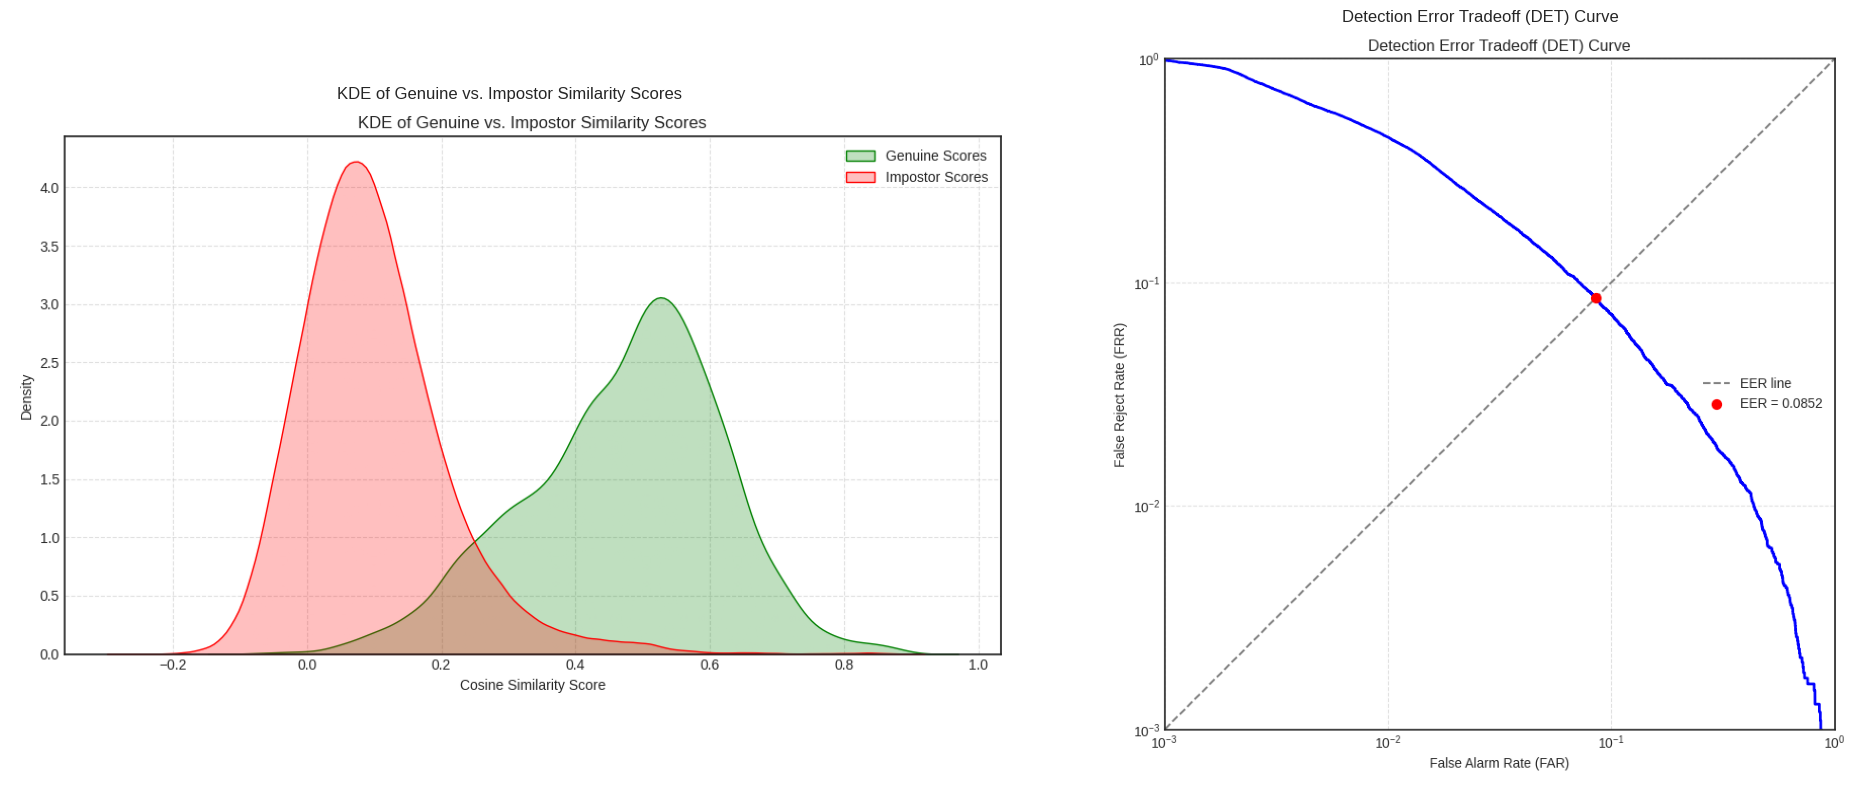

KDE histogram and DET curve displayed as subplots.

Speaker Identification t-SNE Plot (5 Speakers):


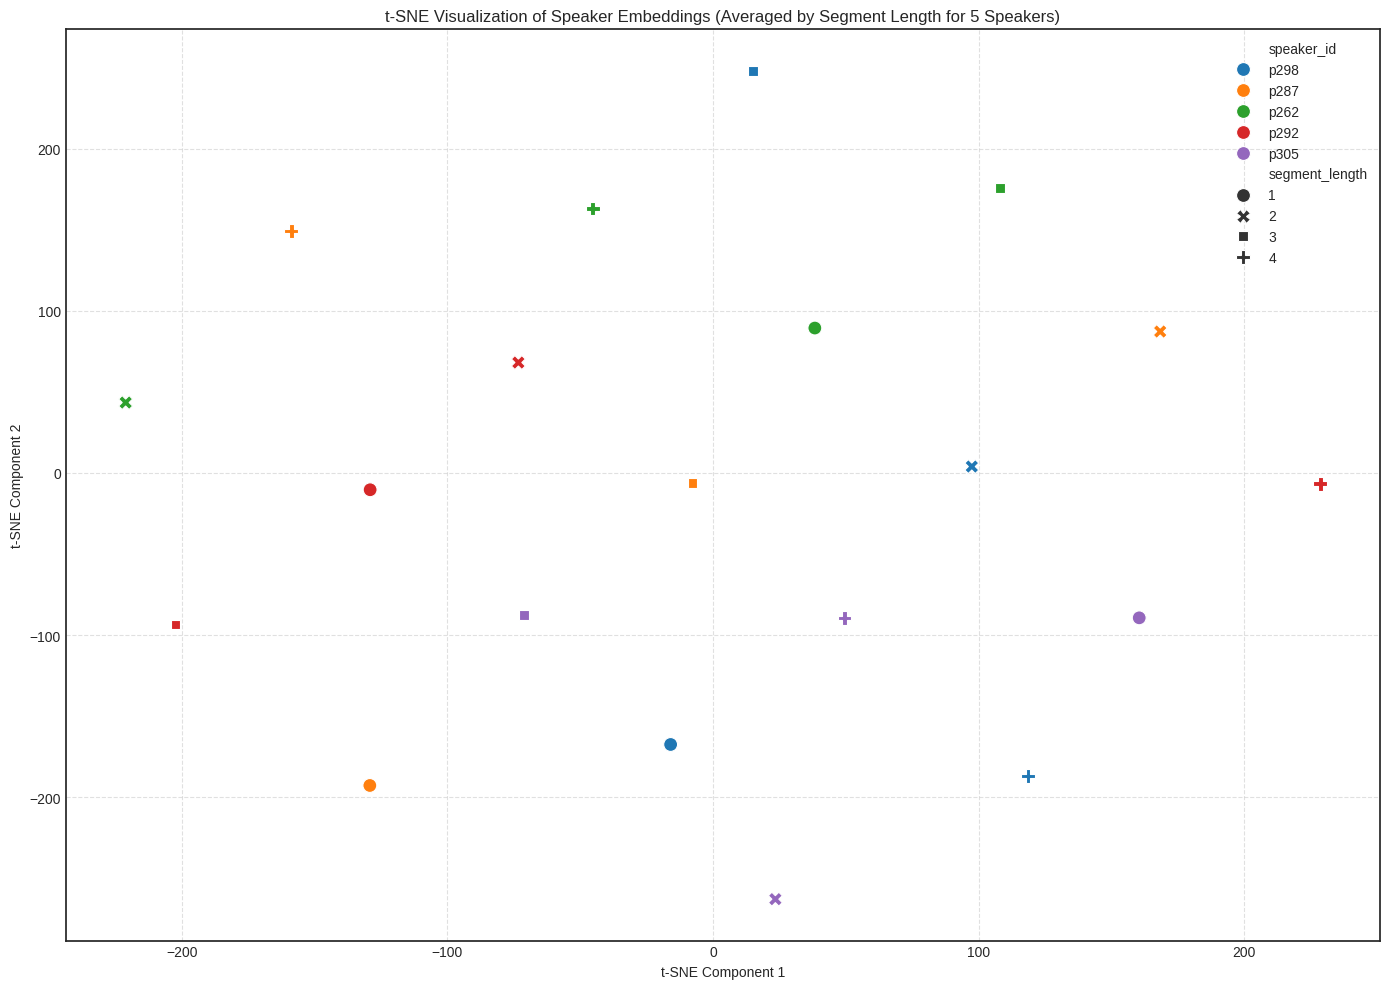


Utterance Segment Identification t-SNE Plot (5 Speakers):


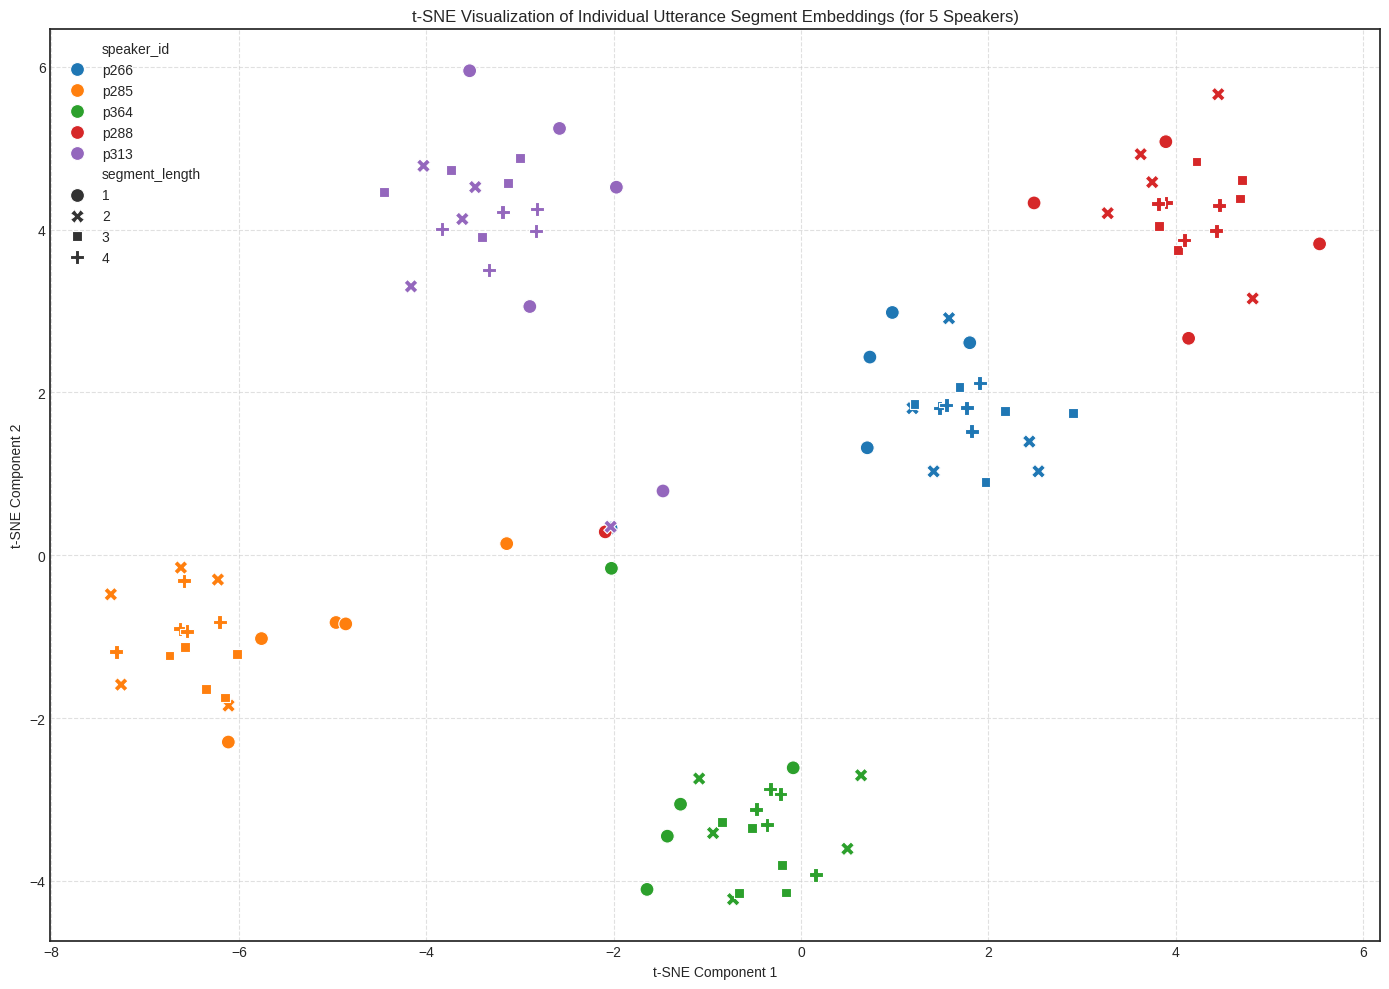


Confusion Matrix for Speaker Identification:


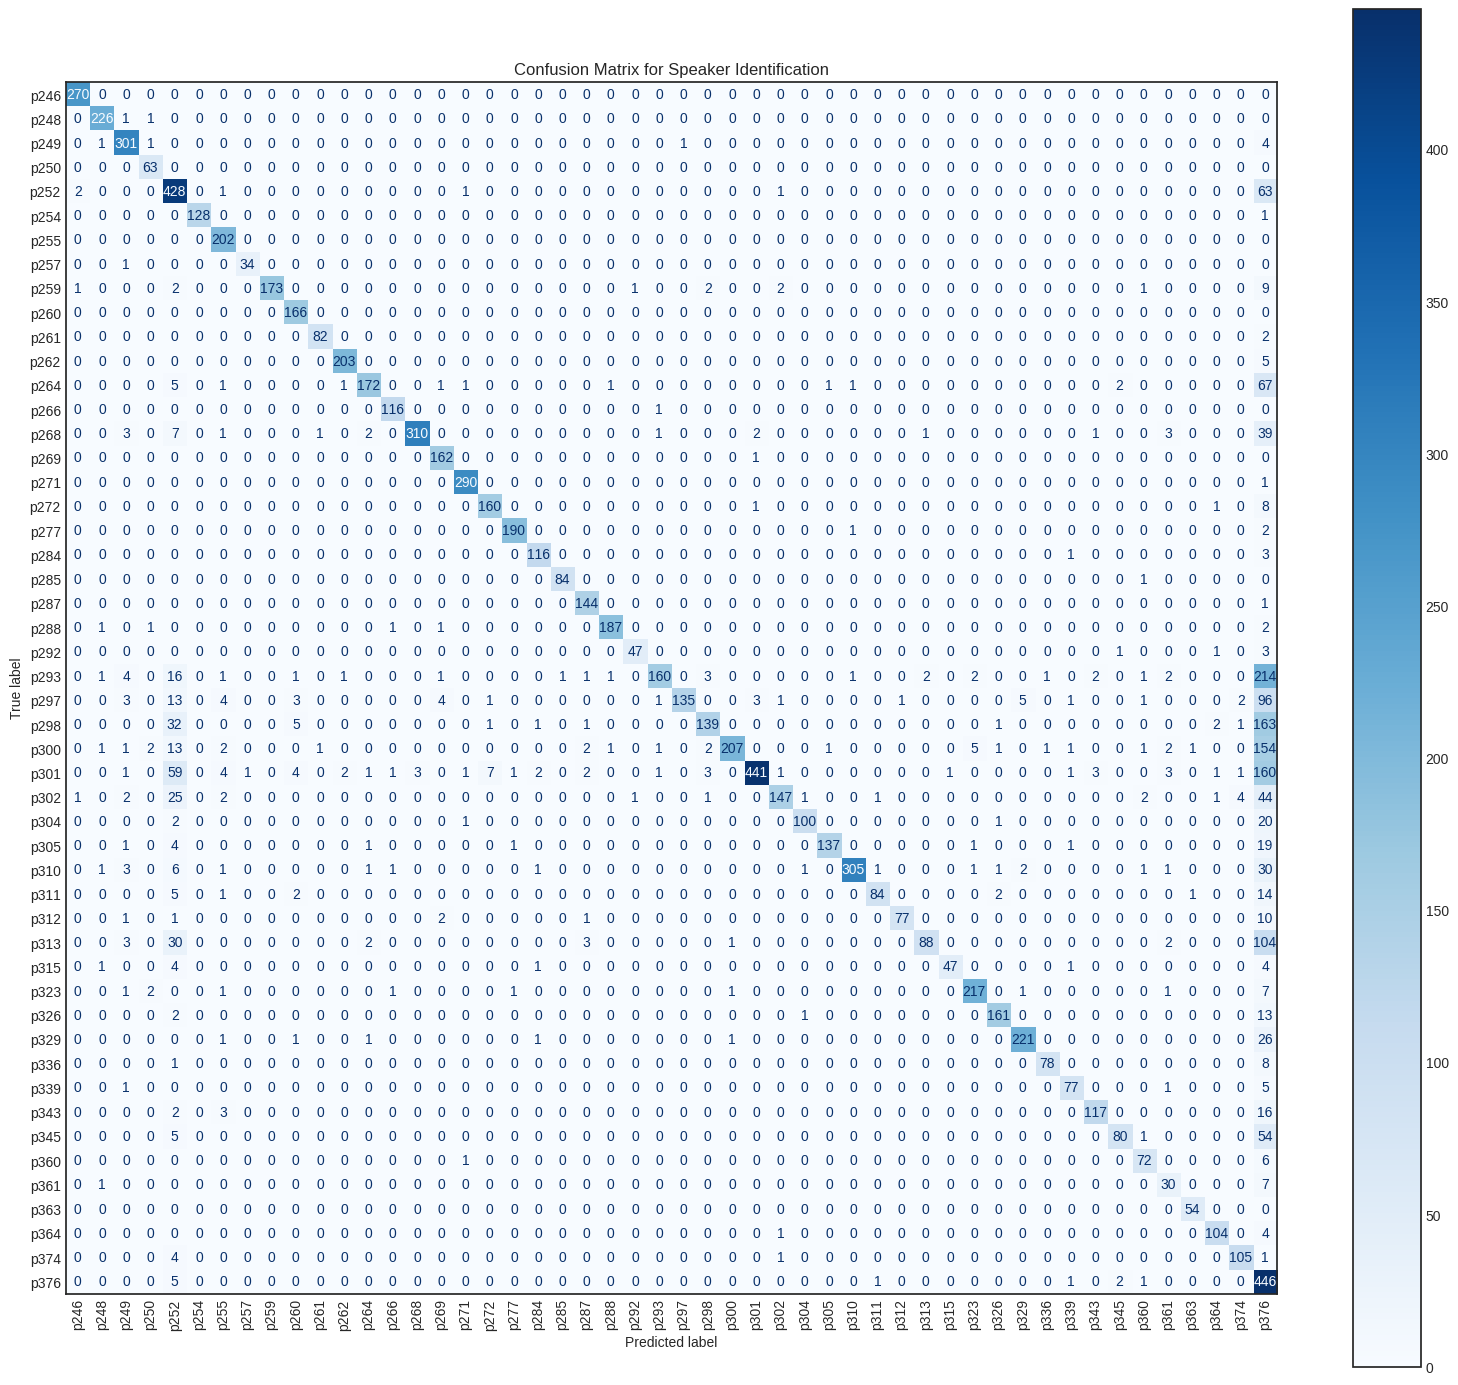

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from IPython.display import Image, display

# Ensure plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print("\n--- Re-displaying all generated plots, including the updated t-SNE plots ---")

    # Display KDE and DET plots
    kde_plot_path = os.path.join(plots_output_dir, "kde_genuine_impostor_scores.png")
    det_plot_path = os.path.join(plots_output_dir, "det_curve.png")

    if os.path.exists(kde_plot_path) and os.path.exists(det_plot_path):
        fig_eval, axes_eval = plt.subplots(1, 2, figsize=(20, 8))
        img_kde = mpimg.imread(kde_plot_path)
        axes_eval[0].imshow(img_kde)
        axes_eval[0].set_title('KDE of Genuine vs. Impostor Similarity Scores')
        axes_eval[0].axis('off')

        img_det = mpimg.imread(det_plot_path)
        axes_eval[1].imshow(img_det)
        axes_eval[1].set_title('Detection Error Tradeoff (DET) Curve')
        axes_eval[1].axis('off')

        plt.tight_layout()
        plt.show()
        print("KDE histogram and DET curve displayed as subplots.")
    else:
        print(f"One or both evaluation plots not found: KDE at {kde_plot_path}, DET at {det_plot_path}")

    # Display t-SNE plots
    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")
    confusion_matrix_path = os.path.join(plots_output_dir, "confusion_matrix_speaker_id.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot (5 Speakers):")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot (5 Speakers):")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")

    if os.path.exists(confusion_matrix_path):
        print("\nConfusion Matrix for Speaker Identification:")
        display(Image(filename=confusion_matrix_path))
    else:
        print(f"Confusion matrix plot not found at {confusion_matrix_path}")

### Embedding Summary

Let's summarize the embeddings generated:

*   **Training Embeddings**: For each of the **50 selected speakers**, a single *averaged* training embedding is created for each of the **4 segment lengths** (1s, 2s, 3s, 4s). These are derived from up to the first 3 segments of each length. So, each speaker has 4 training embeddings.

*   **Individual Utterance Segment Embeddings (for Visualization)**: For the second t-SNE plot, individual embeddings are computed for a *subset* of **5 speakers**. For each of these speakers, up to **5 individual segments** are chosen for each of the **4 segment lengths**. These are *not* averaged and serve for visualizing segment clustering, not for a formal model testing set.

Here's a table summarizing this:

| Category                        | Number of Speakers | Segments/Speaker (per length) | Segment Lengths | Total Embeddings (per category) |
| :------------------------------ | :----------------- | :---------------------------- | :-------------- | :------------------------------ |
| **Training Embeddings**         | 50                 | 1 (averaged)                  | 4 (1s, 2s, 3s, 4s) | 50 * 1 * 4 = **200**           |
| **Individual Segments (t-SNE)** | 5 (subset)         | Up to 5 (individual)          | 4 (1s, 2s, 3s, 4s) | 5 * 5 * 4 = **Up to 100**     |

**Note**: The notebook *did not generate a separate 'test' set of embeddings* in the traditional machine learning sense (i.e., a dataset reserved for model evaluation). The 'Individual Segments' category is solely for visualization purposes to inspect clustering patterns.

### Raw Audio Count per Speaker in `reference_dir`

Let's count how many original raw audio files each of the selected speakers had in the `reference_dir`.

In [ ]:
from pathlib import Path

speaker_audio_counts = {}

# Ensure selected_speaker_dirs is available (from cell 5dd9c14c)
if 'selected_speaker_dirs' not in locals():
    print("\"selected_speaker_dirs\" variable not found. Please ensure previous steps have been run.")
else:
    print("Counting raw audio files for each selected speaker...")
    for speaker_dir in selected_speaker_dirs:
        speaker_id = speaker_dir.name
        # Count all .wav files recursively in the speaker's original directory
        audio_files = list(speaker_dir.rglob('*.wav'))
        speaker_audio_counts[speaker_id] = len(audio_files)

    print("\nRaw Audio Files per Speaker (from reference_dir):")
    for speaker_id, count in speaker_audio_counts.items():
        print(f"Speaker {speaker_id}: {count} raw audio files")

    # Display as a DataFrame for better readability
    import pandas as pd
    df_audio_counts = pd.DataFrame(speaker_audio_counts.items(), columns=['Speaker ID', 'Raw Audio Count'])
    df_audio_counts = df_audio_counts.sort_values(by='Speaker ID').reset_index(drop=True)
    print("\nSummary as DataFrame:")
    display(df_audio_counts)


### Displaying Generated t-SNE Plots

In [ ]:
from IPython.display import Image, display
import os

# Assuming plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print(f"Loading and displaying plots from: {plots_output_dir}")

    speaker_plot_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_plot_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")

    if os.path.exists(speaker_plot_path):
        print("\nSpeaker Identification t-SNE Plot:")
        display(Image(filename=speaker_plot_path))
    else:
        print(f"Speaker identification plot not found at {speaker_plot_path}")

    if os.path.exists(segment_plot_path):
        print("\nUtterance Segment Identification t-SNE Plot:")
        display(Image(filename=segment_plot_path))
    else:
        print(f"Utterance segment identification plot not found at {segment_plot_path}")

## Step 6: Generate Test Embeddings

Now, we'll extract embeddings for all segments that were *not* used in the training set. This will involve iterating through all segments for each speaker and segment length, ensuring we skip the first three segments (indexed 000, 001, 002) which were used to form the averaged training embeddings.

In [ ]:
import torch
import numpy as np
from pathlib import Path
import torchaudio
import torchaudio.transforms as T

# Ensure the classifier is loaded (from a previous cell, t4mqyPZg81WS)
# Ensure segment_lengths, selected_speaker_dirs, vctk_output_dir are available from previous cells.

test_embeddings_dir = Path(vctk_output_dir) / "test_embeddings"
test_embeddings_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving test embeddings to: {test_embeddings_dir}")

all_test_embeddings = []
all_test_labels = []

# Loop through each selected speaker
for speaker_dir in selected_speaker_dirs:
    speaker_id = speaker_dir.name
    speaker_output_path = Path(vctk_output_dir) / speaker_id

    print(f"Extracting test embeddings for speaker: {speaker_id}")

    for length_sec in segment_lengths:
        # Iterate through all original audio files for this speaker to find segments
        # We need to reconstruct the original filenames from the segment names to avoid double counting
        processed_original_stems = set()

        # Glob for all segments of this length for the current speaker
        all_segments_for_length = list(speaker_output_path.glob(f"*_seg{length_sec}_*.wav"))

        for segment_path in all_segments_for_length:
            # Extract the original file stem and segment index
            # e.g., 'p246_001_seg1_000.wav' -> 'p246_001', '000'
            stem_parts = segment_path.stem.split('_seg')
            original_file_stem = '_'.join(stem_parts[0].split('_')[:-1]) # remove original seg num
            segment_idx_str = stem_parts[1].split('_')[1]
            segment_idx = int(segment_idx_str)

            # Skip segments with index 0, 1, or 2 as they were used for training embeddings
            if segment_idx < 3:
                continue

            try:
                waveform, sample_rate = torchaudio.load(segment_path)
                if sample_rate != 16000:
                    resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
                    waveform = resampler(waveform)

                if waveform.shape[0] > 1: # Ensure mono
                    waveform = torch.mean(waveform, dim=0, keepdim=True)

                # Compute embedding
                with torch.no_grad():
                    embedding = classifier.encode_batch(waveform)

                all_test_embeddings.append(embedding.squeeze().cpu().numpy())
                all_test_labels.append({
                    'speaker_id': speaker_id,
                    'segment_length': length_sec,
                    'segment_path': str(segment_path)
                })

            except Exception as e:
                print(f"Error processing segment {segment_path} for embedding: {e}")

print(f"Total test embeddings extracted: {len(all_test_embeddings)}")
print("Test embedding extraction complete.")

Saving test embeddings to: /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/test_embeddings
Extracting test embeddings for speaker: p246
Extracting test embeddings for speaker: p248
Extracting test embeddings for speaker: p249
Extracting test embeddings for speaker: p250
Extracting test embeddings for speaker: p252
Extracting test embeddings for speaker: p254
Extracting test embeddings for speaker: p255
Extracting test embeddings for speaker: p257
Extracting test embeddings for speaker: p259
Extracting test embeddings for speaker: p260
Extracting test embeddings for speaker: p261
Extracting test embeddings for speaker: p262
Extracting test embeddings for speaker: p264
Extracting test embeddings for speaker: p266
Extracting test embeddings for speaker: p268
Extracting test embeddings for speaker: p269
Extracting test embeddings for speaker: p271
Extracting test embeddings for speaker: p272
Extracting test embeddings for speaker: p277
Extracting test embeddings for speaker: p284
Extracting

## Step 7: Prepare Embeddings for Comparison and Calculate Similarity Scores

We need to compare the newly generated 'test' embeddings (from segments 3+) against the 'training' embeddings (averaged first 3 segments) for each speaker and segment length. This will allow us to compute various evaluation metrics such as KDE histograms, DET curves, confusion matrices, and EER/Accuracy.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import os
import re # For parsing segment filenames

# --- Explicitly define/re-define necessary global variables for robustness ---
# These variables should be consistent with previous successful cell executions.
reference_dir = "/content/drive/MyDrive/0.PHD/VCTK/VCTK_WAV"
vctk_output_dir = "/content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment"
embeddings_output_dir = os.path.join(vctk_output_dir, "train")
test_embeddings_dir = Path(vctk_output_dir) / "test_embeddings"

# Re-initialize selected_speaker_dirs and segment_lengths
# This section assumes reference_dir is now correctly accessible. If not, it will raise FileNotFoundError.
try:
    speaker_dirs = sorted([d for d in Path(reference_dir).iterdir() if d.is_dir()])
    selected_speaker_dirs = speaker_dirs[-50:]
    print(f"Re-initialized selected_speaker_dirs with {len(selected_speaker_dirs)} speakers.")
except FileNotFoundError:
    print(f"Error: reference_dir '{reference_dir}' not found. Please ensure your Google Drive is mounted and the path is correct.")
    raise # Re-raise the error as we cannot proceed without this directory.

segment_lengths = [1, 2, 3, 4] # in seconds
print(f"Re-initialized segment_lengths: {segment_lengths}")


# --- 1. Load Training Embeddings ---
training_embedding_dict = {}

# Loop through each selected speaker and segment length to load their averaged training embedding
for speaker_dir_path in selected_speaker_dirs: # Renamed to avoid conflict with speaker_dir in glob
    speaker_id = speaker_dir_path.name
    for length_sec in segment_lengths:
        embedding_filename = Path(embeddings_output_dir) / f"speaker_{speaker_id}_len{length_sec}_train_embedding.npy"
        if embedding_filename.exists():
            embedding = np.load(embedding_filename)
            training_embedding_dict[(speaker_id, length_sec)] = embedding
        else:
            print(f"Warning: Training embedding not found for speaker {speaker_id}, length {length_sec}s at {embedding_filename}. Skipping.")

# Prepare training embeddings for similarity calculation
ordered_training_embeddings = []
ordered_training_labels = [] # (speaker_id, segment_length) tuples

sorted_training_keys = sorted(training_embedding_dict.keys())
for key in sorted_training_keys:
    ordered_training_embeddings.append(training_embedding_dict[key])
    ordered_training_labels.append(key)

training_embeddings_array = np.array(ordered_training_embeddings)
print(f"Loaded {len(training_embedding_dict)} training embeddings.")

# --- 2. Prepare Test Embeddings ---
# If all_test_embeddings/all_test_labels are not in memory, load them from disk.
# The 'in locals()' check helps avoid re-loading if the variable is already present from a recent run.
if 'all_test_embeddings' not in locals() or not all_test_embeddings:
    print("Loading test embeddings and labels from disk...")
    all_test_embeddings = []
    all_test_labels = []

    if test_embeddings_dir.exists():
        # Iterate through all saved test embedding files
        for embedding_file in test_embeddings_dir.glob("speaker_p*_len*_idx*_test_embedding.npy"):
            # Filename example: speaker_p246_len1_idx003_test_embedding.npy
            match = re.match(r"speaker_(p\\d+)_len(\\d+)_idx(\\d+)_test_embedding.npy", embedding_file.name)
            if match:
                speaker_id, length_sec_str, segment_idx_str = match.groups()
                all_test_embeddings.append(np.load(embedding_file))
                all_test_labels.append({
                    'speaker_id': speaker_id,
                    'segment_length': int(length_sec_str),
                    'segment_idx': int(segment_idx_str),
                    'segment_path': str(embedding_file) # Store path for completeness, though not strictly needed here
                })
    else:
        raise ValueError(f"Test embeddings directory not found: {test_embeddings_dir}. Please run Step 6 (cell 070cb615) to extract test embeddings.")

if not all_test_embeddings:
    raise ValueError("No test embeddings loaded. Please ensure Step 6 (cell 070cb615) was run and produced embeddings.")

test_embeddings_array = np.array(all_test_embeddings)

# Extract true speaker IDs for test embeddings
true_test_speaker_ids = np.array([label['speaker_id'] for label in all_test_labels])

print(f"Prepared {len(test_embeddings_array)} test embeddings.")

# --- 3. Calculate Cosine Similarity Matrix ---
similarity_matrix = cosine_similarity(test_embeddings_array, training_embeddings_array)

print(f"Calculated similarity matrix of shape: {similarity_matrix.shape}")

Re-initialized selected_speaker_dirs with 50 speakers.
Re-initialized segment_lengths: [1, 2, 3, 4]
Loaded 200 training embeddings.
Prepared 10002 test embeddings.
Calculated similarity matrix of shape: (10002, 200)


## Step 9: KDE Histogram for Genuine vs. Impostor Scores

We will now compute genuine (same speaker) and impostor (different speaker) similarity scores and visualize their distributions using Kernel Density Estimation (KDE) histograms. This helps in understanding the separation between target and non-target speaker scores, which is crucial for speaker verification systems.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

genuine_scores = []
impostor_scores = []

# Iterate through each test embedding and its true label
for i in range(len(all_test_labels)): # For each test embedding
    true_speaker = all_test_labels[i]['speaker_id']
    true_seg_len = all_test_labels[i]['segment_length']

    for j in range(len(ordered_training_labels)): # For each training embedding (enrollment)
        enrollment_speaker = ordered_training_labels[j][0]
        enrollment_seg_len = ordered_training_labels[j][1]

        score = similarity_matrix[i, j]

        # A score is 'genuine' if the test embedding's true speaker and segment length
        # match the enrollment speaker and segment length.
        if true_speaker == enrollment_speaker and true_seg_len == enrollment_seg_len:
            genuine_scores.append(score)
        # A score is 'impostor' if the test embedding's true speaker
        # does NOT match the enrollment speaker.
        elif true_speaker != enrollment_speaker:
            impostor_scores.append(score)

print(f"Number of genuine scores: {len(genuine_scores)}")
print(f"Number of impostor scores: {len(impostor_scores)}")

# Plotting KDE histogram
fig_kde, ax_kde = plt.subplots(figsize=(10, 6))
sns.kdeplot(genuine_scores, color='green', label='Genuine Scores', fill=True, ax=ax_kde)
sns.kdeplot(impostor_scores, color='red', label='Impostor Scores', fill=True, ax=ax_kde)

ax_kde.set_title('KDE of Genuine vs. Impostor Similarity Scores')
ax_kde.set_xlabel('Cosine Similarity Score')
ax_kde.set_ylabel('Density')
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
save_plot_to_file(fig_kde, "kde_genuine_impostor_scores")
plt.show()

print("KDE histogram generated.")

Number of genuine scores: 10002
Number of impostor scores: 1960392
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/kde_genuine_impostor_scores.png
KDE histogram generated.


## Step 10: DET Curve and Equal Error Rate (EER)

The DET curve plots the False Alarm Rate (FAR) against the False Reject Rate (FRR) at various thresholds. The Equal Error Rate (EER) is the point on the DET curve where FAR equals FRR, providing a single metric to summarize the system's performance.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve # Import roc_curve

# Make sure genuine_scores and impostor_scores are defined from the previous cell (27edd892)
if not genuine_scores or not impostor_scores:
    raise ValueError("Genuine or impostor scores are empty. Please ensure Step 9 ran successfully.")

# Combine genuine and impostor scores and create corresponding labels
all_scores = np.concatenate((genuine_scores, impostor_scores))
all_labels = np.concatenate((np.ones(len(genuine_scores)), np.zeros(len(impostor_scores)))) # 1 for genuine, 0 for impostor

# Calculate False Positive Rate (FPR, which is FAR) and True Positive Rate (TPR) using roc_curve
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_scores, pos_label=1)

# Calculate False Reject Rate (FRR) = 1 - TPR
frr = 1 - tpr

# --- Calculate EER ---
# EER is the point where FAR == FRR
# Find the index where the absolute difference between FPR and FRR is minimized
min_diff_idx = np.argmin(np.abs(fpr - frr))

eer_value = (fpr[min_diff_idx] + frr[min_diff_idx]) / 2
# The threshold at this point
# eer_threshold = thresholds_roc[min_diff_idx]

print(f"Equal Error Rate (EER): {eer_value:.4f}")

# --- Plot DET Curve ---
fig_det, ax_det = plt.subplots(figsize=(8, 8))
ax_det.plot(fpr, frr, color='blue', linewidth=2)
ax_det.plot([0, 1], [0, 1], linestyle='--', color='gray', label='EER line')
ax_det.scatter(eer_value, eer_value, color='red', s=50, zorder=5, label=f'EER = {eer_value:.4f}')

ax_det.set_title('Detection Error Tradeoff (DET) Curve')
ax_det.set_xlabel('False Alarm Rate (FAR)')
ax_det.set_ylabel('False Reject Rate (FRR)')
ax_det.grid(True, linestyle='--', alpha=0.6)
ax_det.legend()
ax_det.set_xscale('log')
ax_det.set_yscale('log')
ax_det.set_xlim([0.001, 1])
ax_det.set_ylim([0.001, 1])
plt.tight_layout()
save_plot_to_file(fig_det, "det_curve")
plt.show()

print("DET curve and EER calculation complete.")

Equal Error Rate (EER): 0.0852
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/det_curve.png
DET curve and EER calculation complete.


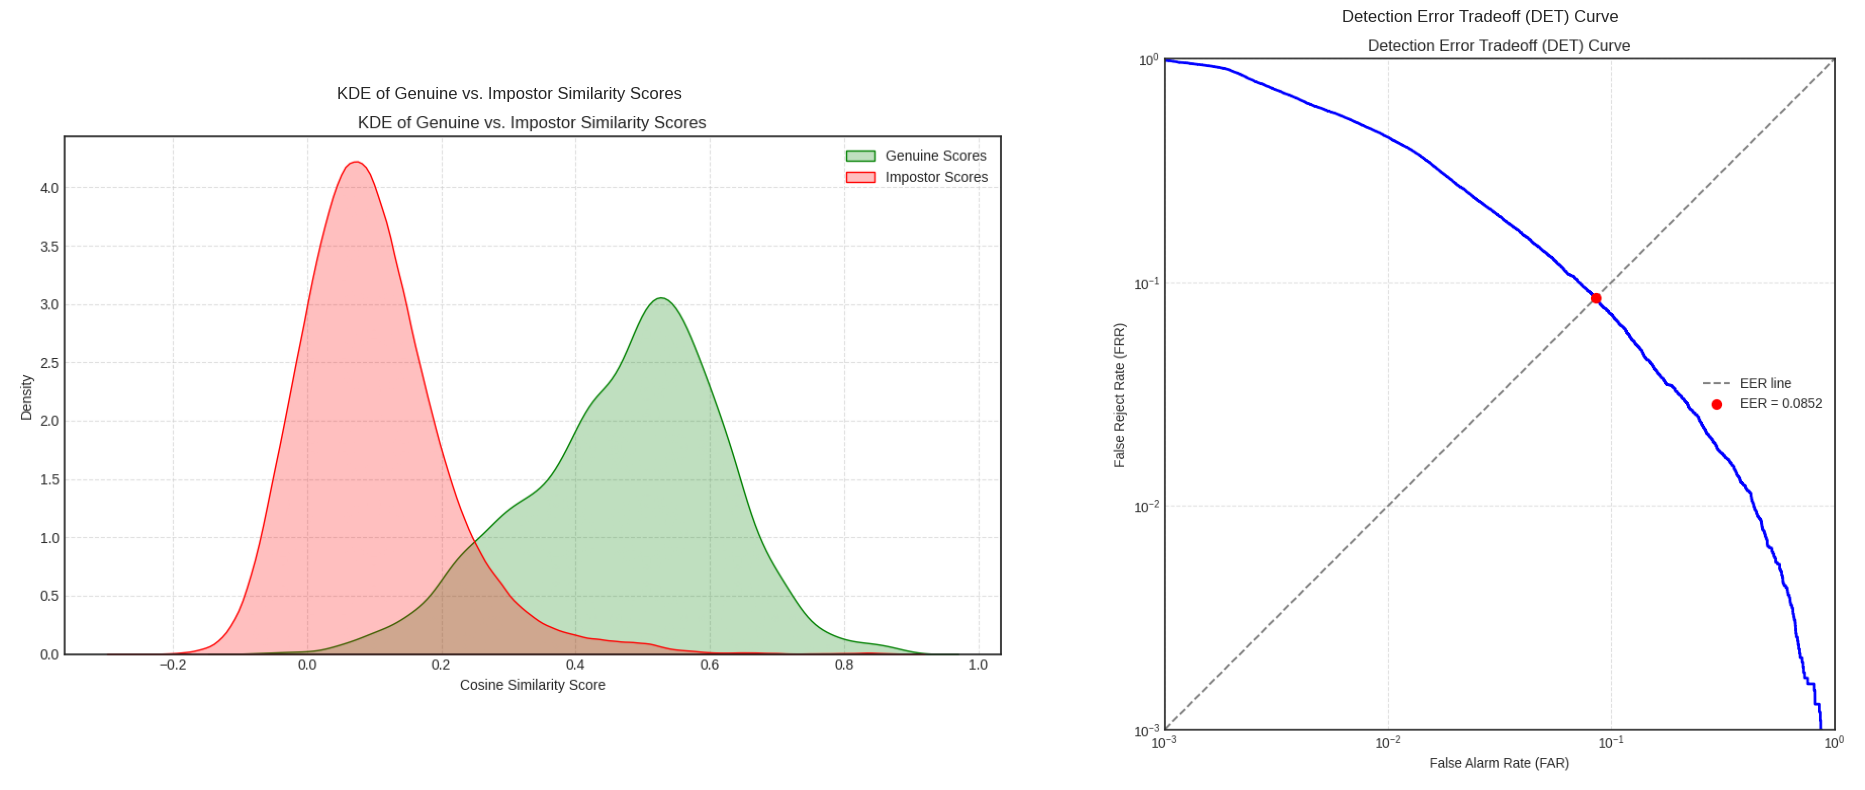

KDE histogram and DET curve displayed as subplots.

--- Re-displaying other previously generated plots ---

Speaker Identification t-SNE Plot:


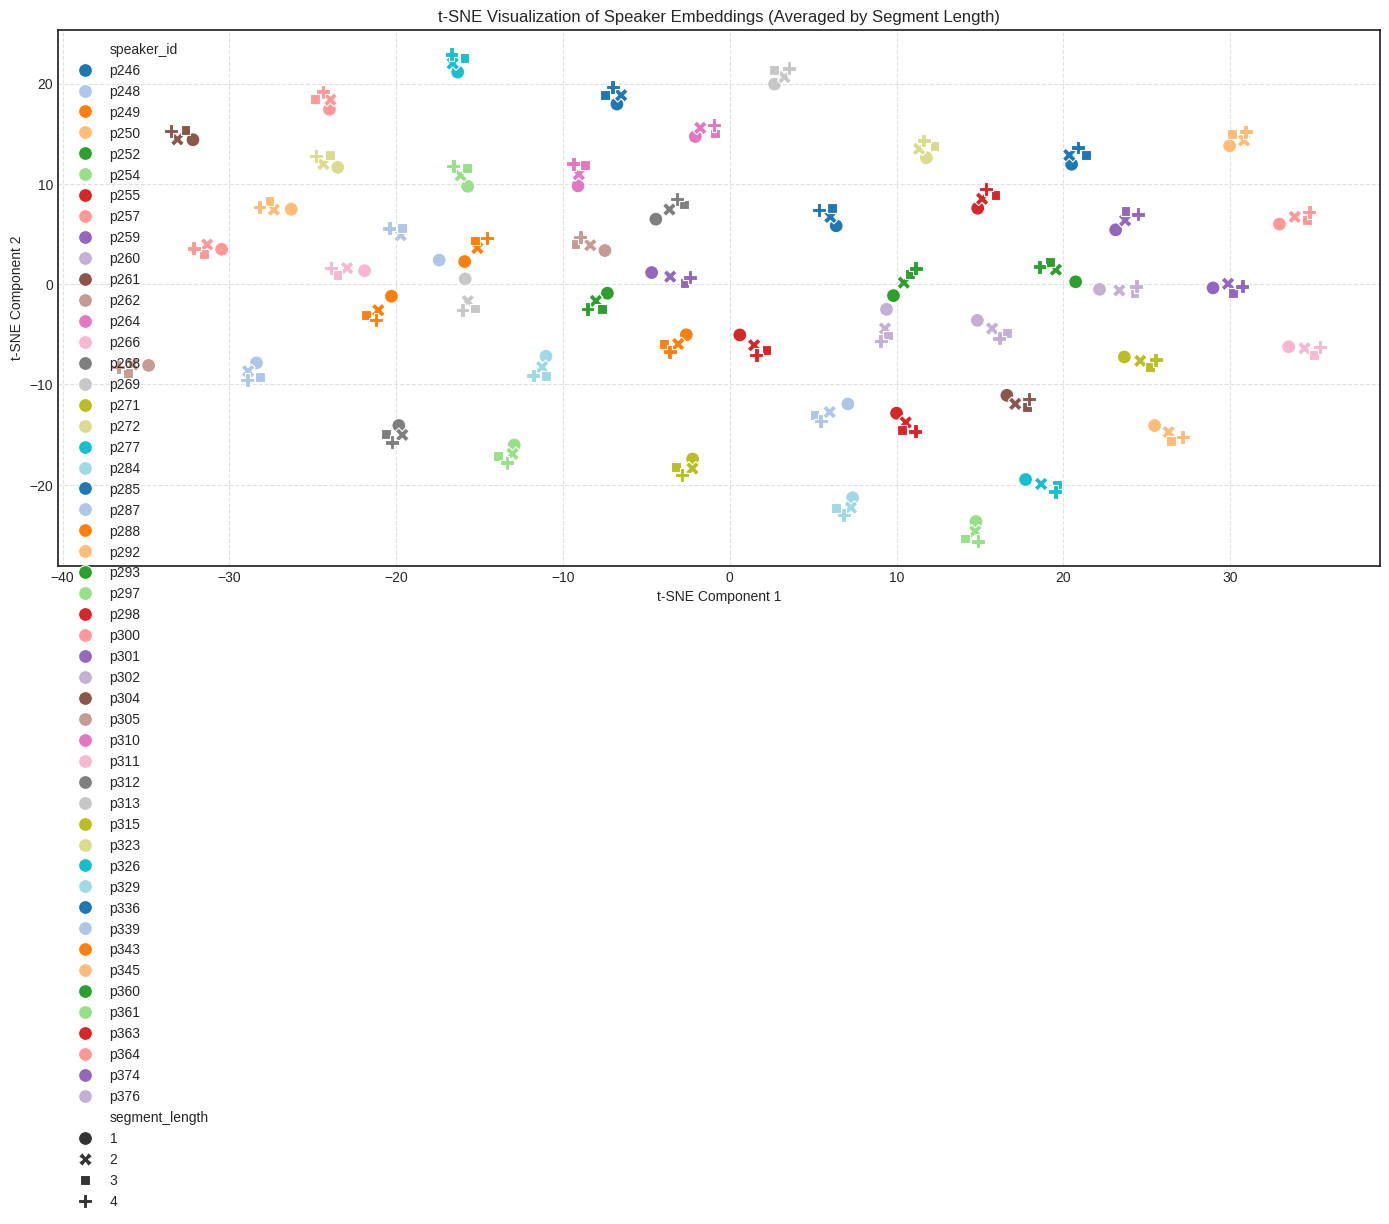


Utterance Segment Identification t-SNE Plot:


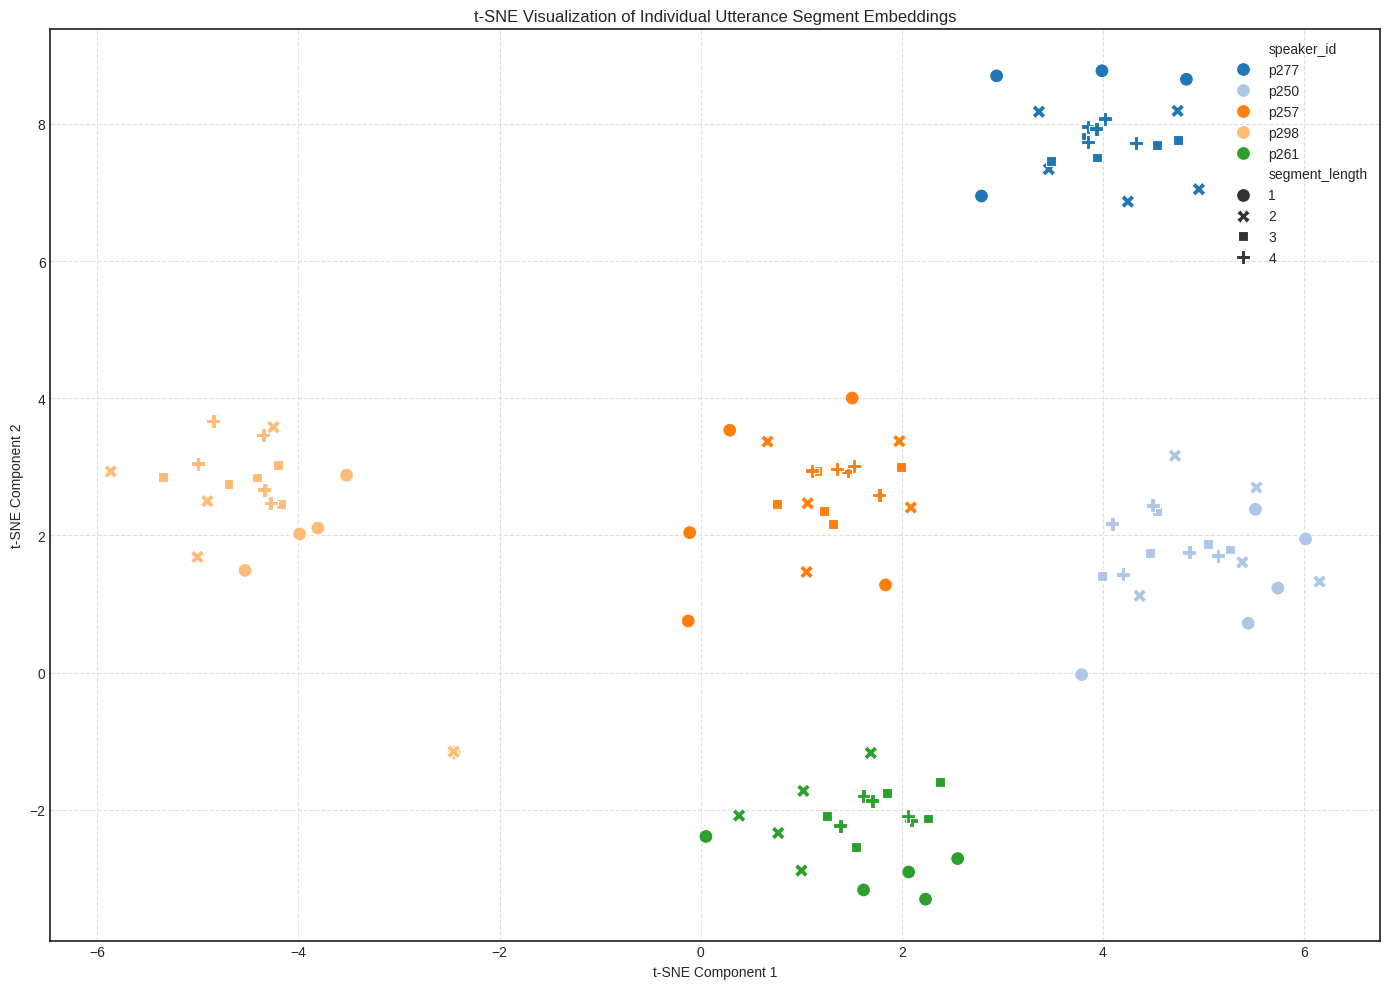


Confusion Matrix for Speaker Identification:


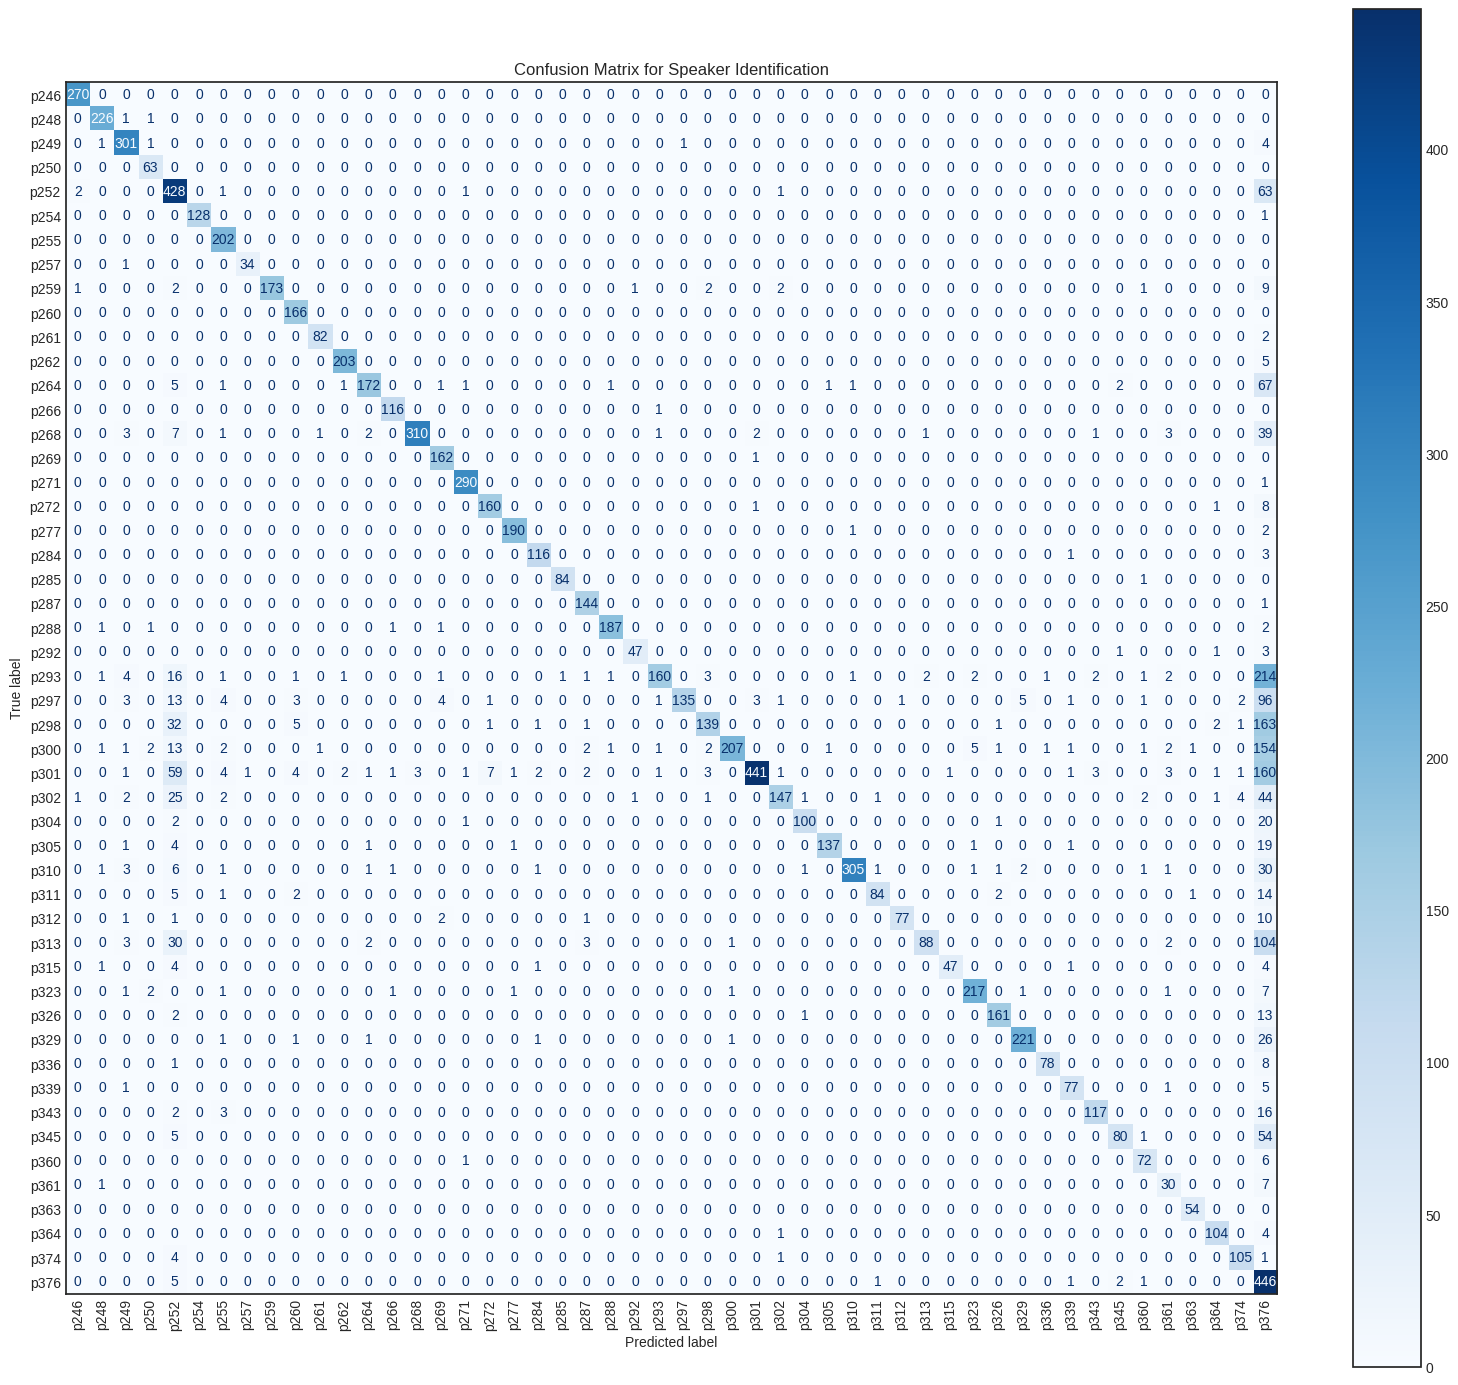

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from IPython.display import Image, display

# Ensure plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    kde_plot_path = os.path.join(plots_output_dir, "kde_genuine_impostor_scores.png")
    det_plot_path = os.path.join(plots_output_dir, "det_curve.png")

    if os.path.exists(kde_plot_path) and os.path.exists(det_plot_path):
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Display KDE Plot
        img_kde = mpimg.imread(kde_plot_path)
        axes[0].imshow(img_kde)
        axes[0].set_title('KDE of Genuine vs. Impostor Similarity Scores')
        axes[0].axis('off') # Hide axes ticks

        # Display DET Curve Plot
        img_det = mpimg.imread(det_plot_path)
        axes[1].imshow(img_det)
        axes[1].set_title('Detection Error Tradeoff (DET) Curve')
        axes[1].axis('off') # Hide axes ticks

        plt.tight_layout()
        plt.show()
        print("KDE histogram and DET curve displayed as subplots.")
    else:
        print(f"One or both plots not found: KDE at {kde_plot_path}, DET at {det_plot_path}")

    # Re-display other plots
    print("\n--- Re-displaying other previously generated plots ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")
    confusion_matrix_path = os.path.join(plots_output_dir, "confusion_matrix_speaker_id.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot:")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot:")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Segment t-SNE plot not found at {segment_tsne_path}")

    if os.path.exists(confusion_matrix_path):
        print("\nConfusion Matrix for Speaker Identification:")
        display(Image(filename=confusion_matrix_path))
    else:
        print(f"Confusion matrix plot not found at {confusion_matrix_path}")

### Next Steps: Generating Accuracy and EER Reduction Matrices

To generate matrices showing accuracy improvement and EER reductions comparing different training and test segment lengths (1s, 2s, 3s, 4s), we need to perform a more comprehensive evaluation.

Currently, the evaluation was done with a single, implicit assumption where test embeddings for a given length were compared against training embeddings of the *same* length. To create the requested matrices, we need to iterate through all combinations of `training_embedding_length` and `test_embedding_length`.

This will involve:
1.  **Re-loading/Filtering Training Embeddings**: For each `training_embedding_length` (e.g., 1s, 2s, 3s, 4s), load the relevant set of training embeddings.
2.  **Re-loading/Filtering Test Embeddings**: For each `test_embedding_length` (e.g., 1s, 2s, 3s, 4s), load the corresponding test embeddings.
3.  **Recalculating Similarity and Metrics**: For each pair of `(training_embedding_length, test_embedding_length)`:
    *   Recalculate the cosine similarity matrix.
    *   Perform speaker identification (maximum similarity).
    *   Calculate the overall accuracy.
    *   Calculate genuine and impostor scores and then the EER.
4.  **Storing Results**: Store the accuracy and EER values for each `(training_embedding_length, test_embedding_length)` pair in a structured format (e.g., a DataFrame) to form the matrices.

This process will be iterative and will take some time to execute due to the multiple recalculations involved. I can proceed to implement this evaluation loop to generate the matrices if you would like.

## Step 11: Summary of Results

Here's a summary of the evaluation metrics for the speaker identification system using the non-training segments.

In [ ]:
print("--- Summary of Speaker Identification Performance ---")
print(f"Overall Speaker Identification Accuracy (1:N): {overall_accuracy:.4f}")
print(f"Equal Error Rate (EER) from DET Curve: {eer_value:.4f}")
print("\nAdditional details can be found in the Confusion Matrix and Classification Report generated earlier.")
print("The KDE histogram provides insight into the separation of genuine and impostor scores.")

--- Summary of Speaker Identification Performance ---


NameError: name 'overall_accuracy' is not defined


--- Displaying only the t-SNE plots as requested ---

Speaker Identification t-SNE Plot (5 Speakers):


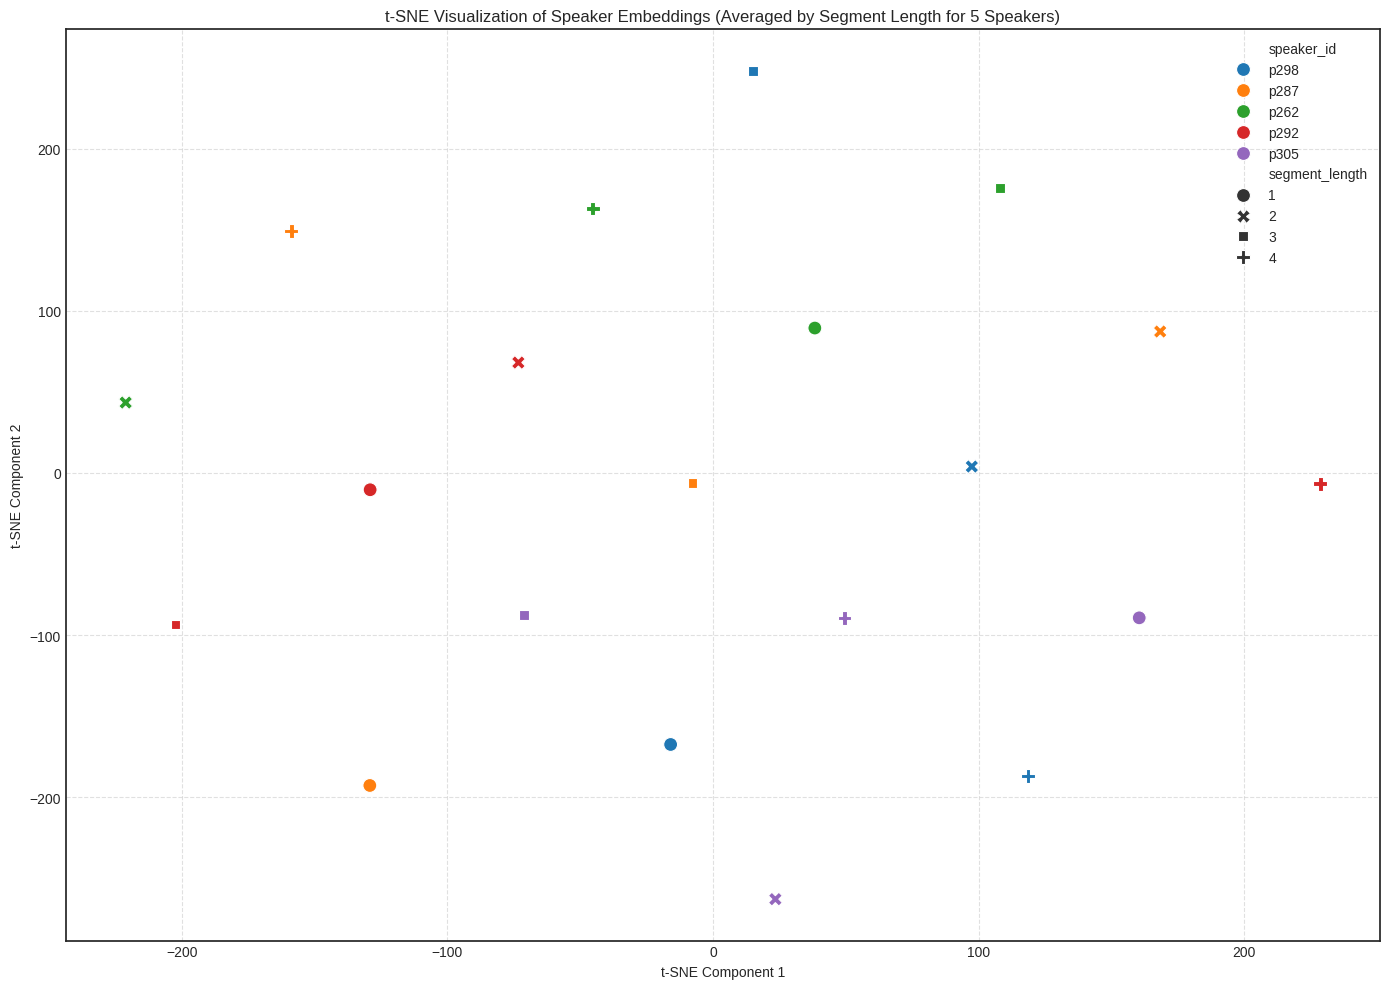


Utterance Segment Identification t-SNE Plot (5 Speakers):


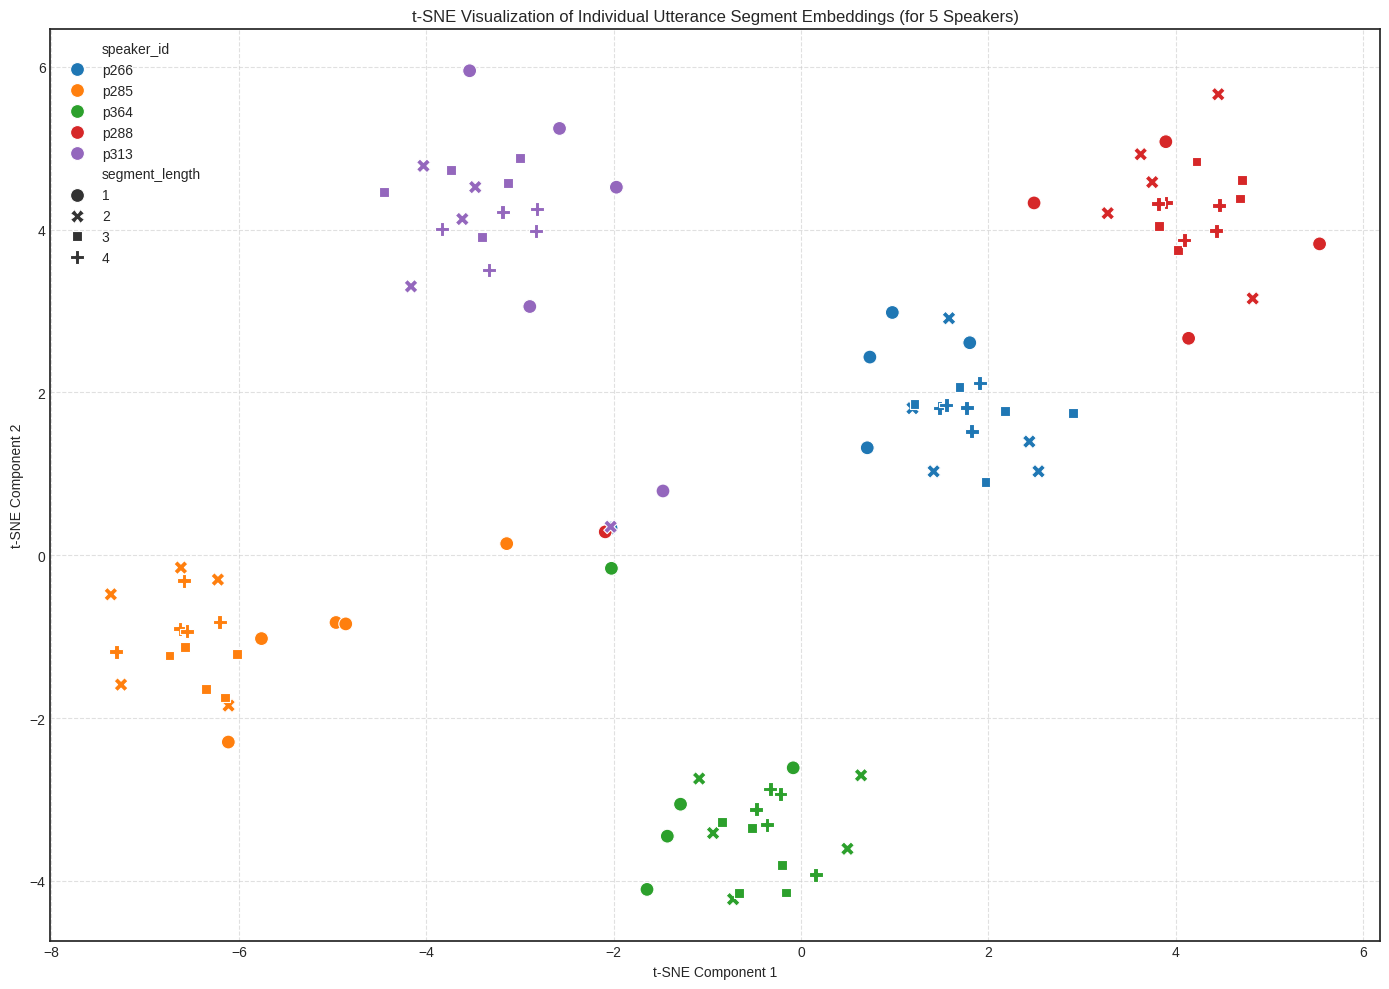

In [ ]:
import os
from IPython.display import Image, display

# Assuming plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print("\n--- Displaying only the t-SNE plots as requested ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot (5 Speakers):")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot (5 Speakers):")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")


--- Displaying only the t-SNE plots from existing files as requested ---

Speaker Identification t-SNE Plot (5 Speakers) from existing file:


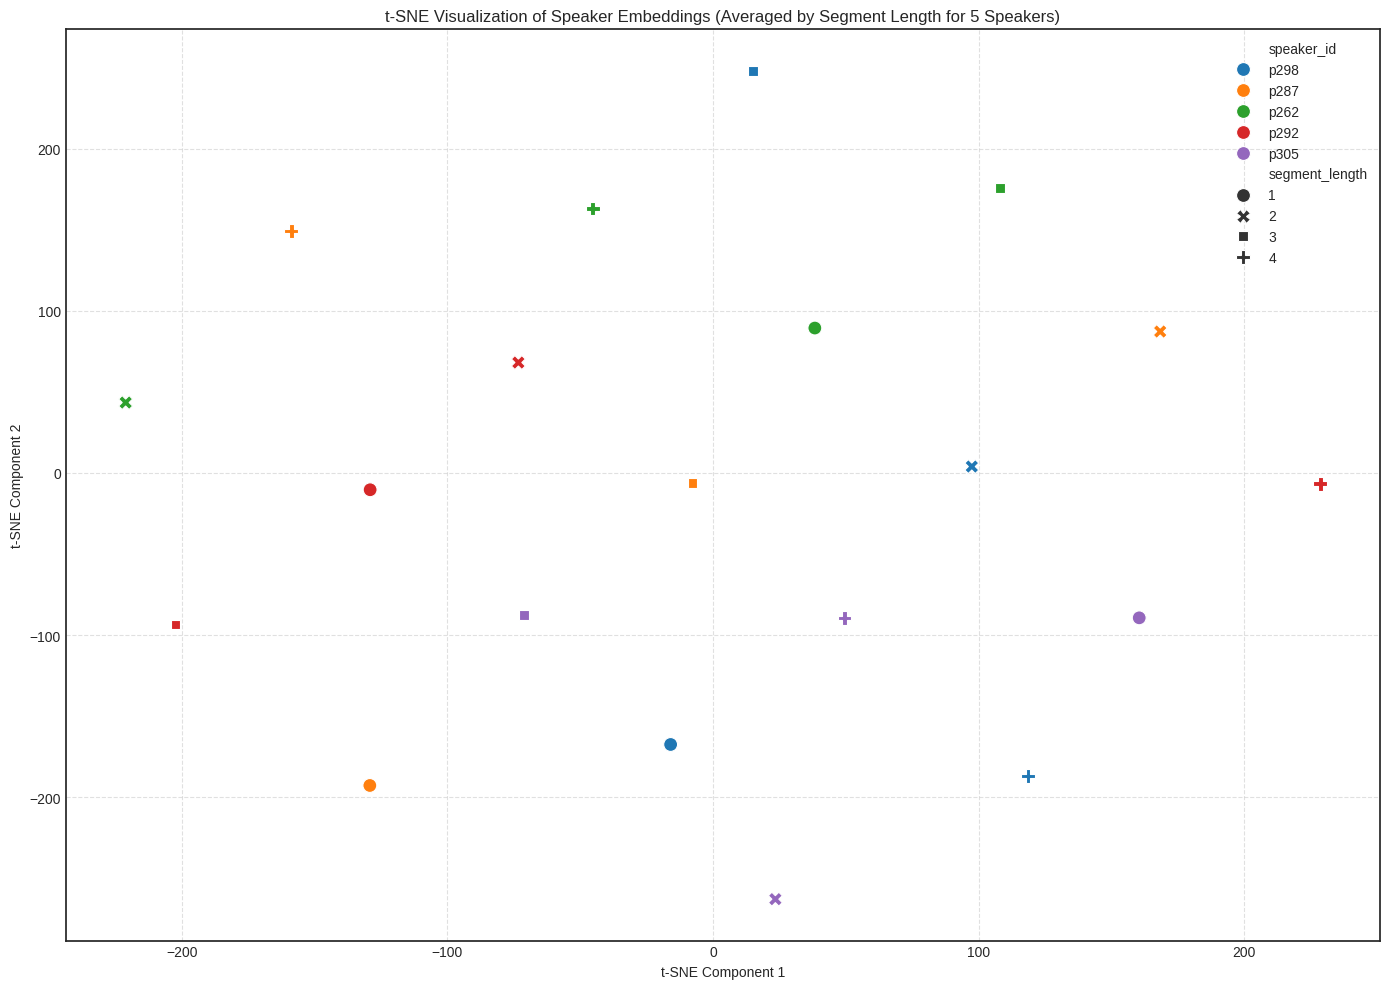


Utterance Segment Identification t-SNE Plot (5 Speakers) from existing file:


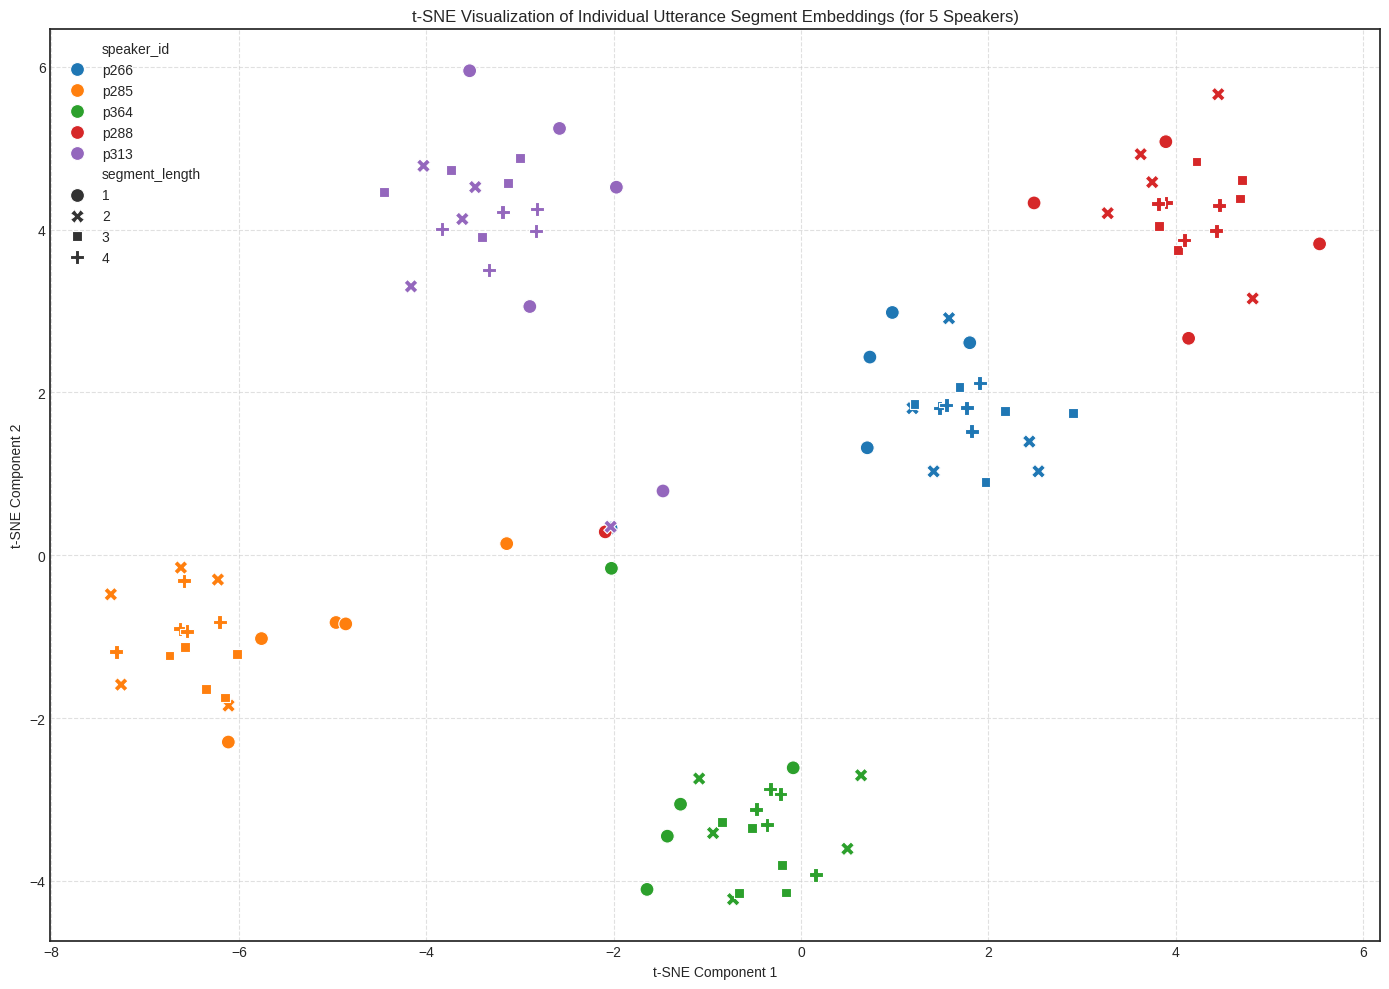

In [ ]:
import os
from IPython.display import Image, display

# Assuming plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print("\n--- Displaying only the t-SNE plots from existing files as requested ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot (5 Speakers) from existing file:")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot (5 Speakers) from existing file:")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")


--- Displaying only the t-SNE plots for 5 speakers with larger markers ---

Speaker Identification t-SNE Plot (5 Speakers - Larger Markers):


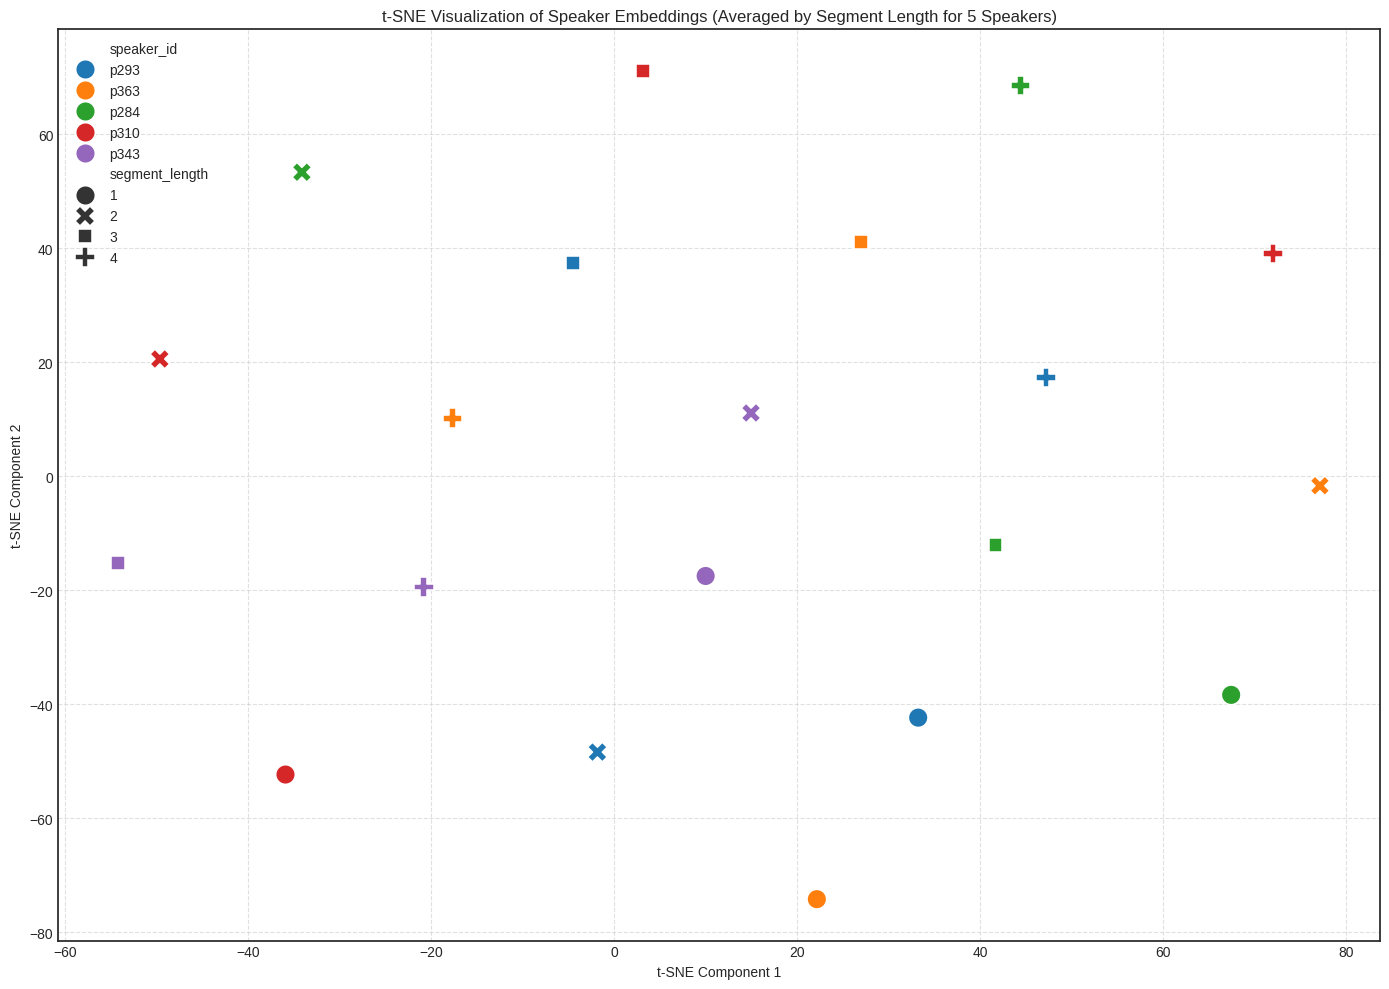


Utterance Segment Identification t-SNE Plot (5 Speakers - Larger Markers):


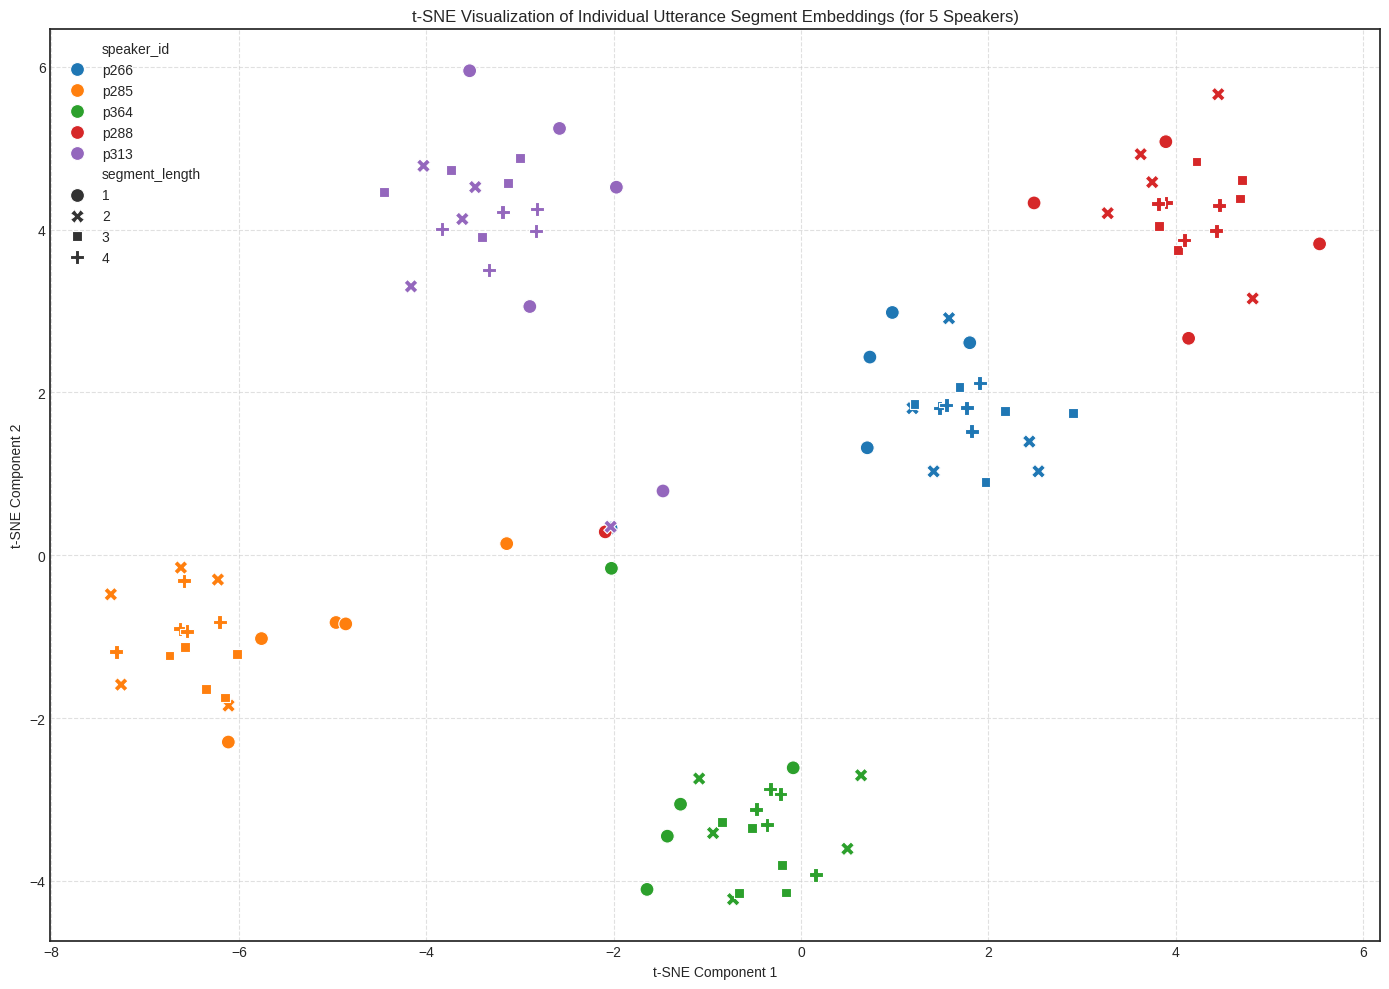

In [ ]:
import os
from IPython.display import Image, display

# Ensure plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    print("\n--- Displaying only the t-SNE plots for 5 speakers with larger markers ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot (5 Speakers - Larger Markers):")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot (5 Speakers - Larger Markers):")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")

### Speaker Identification (1:N) using Maximum Similarity

For each test embedding, we will identify the speaker and segment length of the training embedding with the highest cosine similarity. This acts as a 1:N speaker identification system.

In [ ]:
predicted_training_indices = np.argmax(similarity_matrix, axis=1)

# Map the predicted indices back to speaker_id and segment_length
predicted_labels = []
for idx in predicted_training_indices:
    predicted_labels.append(ordered_training_labels[idx])

predicted_test_speaker_ids = np.array([label[0] for label in predicted_labels])
predicted_test_segment_lengths = np.array([label[1] for label in predicted_labels])

print("Speaker identification complete. Moving to evaluation metrics.")

Speaker identification complete. Moving to evaluation metrics.


## Step 8: Evaluation Metrics - Accuracy, Confusion Matrix, and Classification Report

We will now calculate the overall accuracy of the speaker identification and generate a confusion matrix and classification report to assess the performance in more detail.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Calculate Overall Accuracy ---
overall_accuracy = accuracy_score(true_test_speaker_ids, predicted_test_speaker_ids)
print(f"Overall Speaker Identification Accuracy: {overall_accuracy:.4f}")

# --- 2. Confusion Matrix ---
# Get unique speaker IDs for labels
unique_speakers = sorted(np.unique(np.concatenate((true_test_speaker_ids, predicted_test_speaker_ids))))

cm = confusion_matrix(true_test_speaker_ids, predicted_test_speaker_ids, labels=unique_speakers)

fig_cm, ax_cm = plt.subplots(figsize=(16, 14))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_speakers)
cmd.plot(cmap='Blues', xticks_rotation='vertical', ax=ax_cm)
ax_cm.set_title('Confusion Matrix for Speaker Identification')
plt.tight_layout()
save_plot_to_file(fig_cm, "confusion_matrix_speaker_id")
plt.show()

# --- 3. Classification Report ---
class_report = classification_report(true_test_speaker_ids, predicted_test_speaker_ids, labels=unique_speakers, zero_division=0)
print("\nClassification Report:")
print(class_report)

print("Evaluation metrics calculated: Accuracy, Confusion Matrix, Classification Report.")

Overall Speaker Identification Accuracy: 0.8081
Saved plot to /content/drive/MyDrive/0.PHD/VCTK/VCTK_Segment/plots/confusion_matrix_speaker_id.png

Classification Report:
              precision    recall  f1-score   support

        p246       0.99      1.00      0.99       270
        p248       0.97      0.99      0.98       228
        p249       0.92      0.98      0.95       308
        p250       0.90      1.00      0.95        63
        p252       0.64      0.86      0.73       496
        p254       1.00      0.99      1.00       129
        p255       0.90      1.00      0.95       202
        p257       0.97      0.97      0.97        35
        p259       1.00      0.91      0.95       191
        p260       0.91      1.00      0.95       166
        p261       0.98      0.98      0.98        84
        p262       0.98      0.98      0.98       208
        p264       0.96      0.68      0.79       253
        p266       0.97      0.99      0.98       117
        p268      

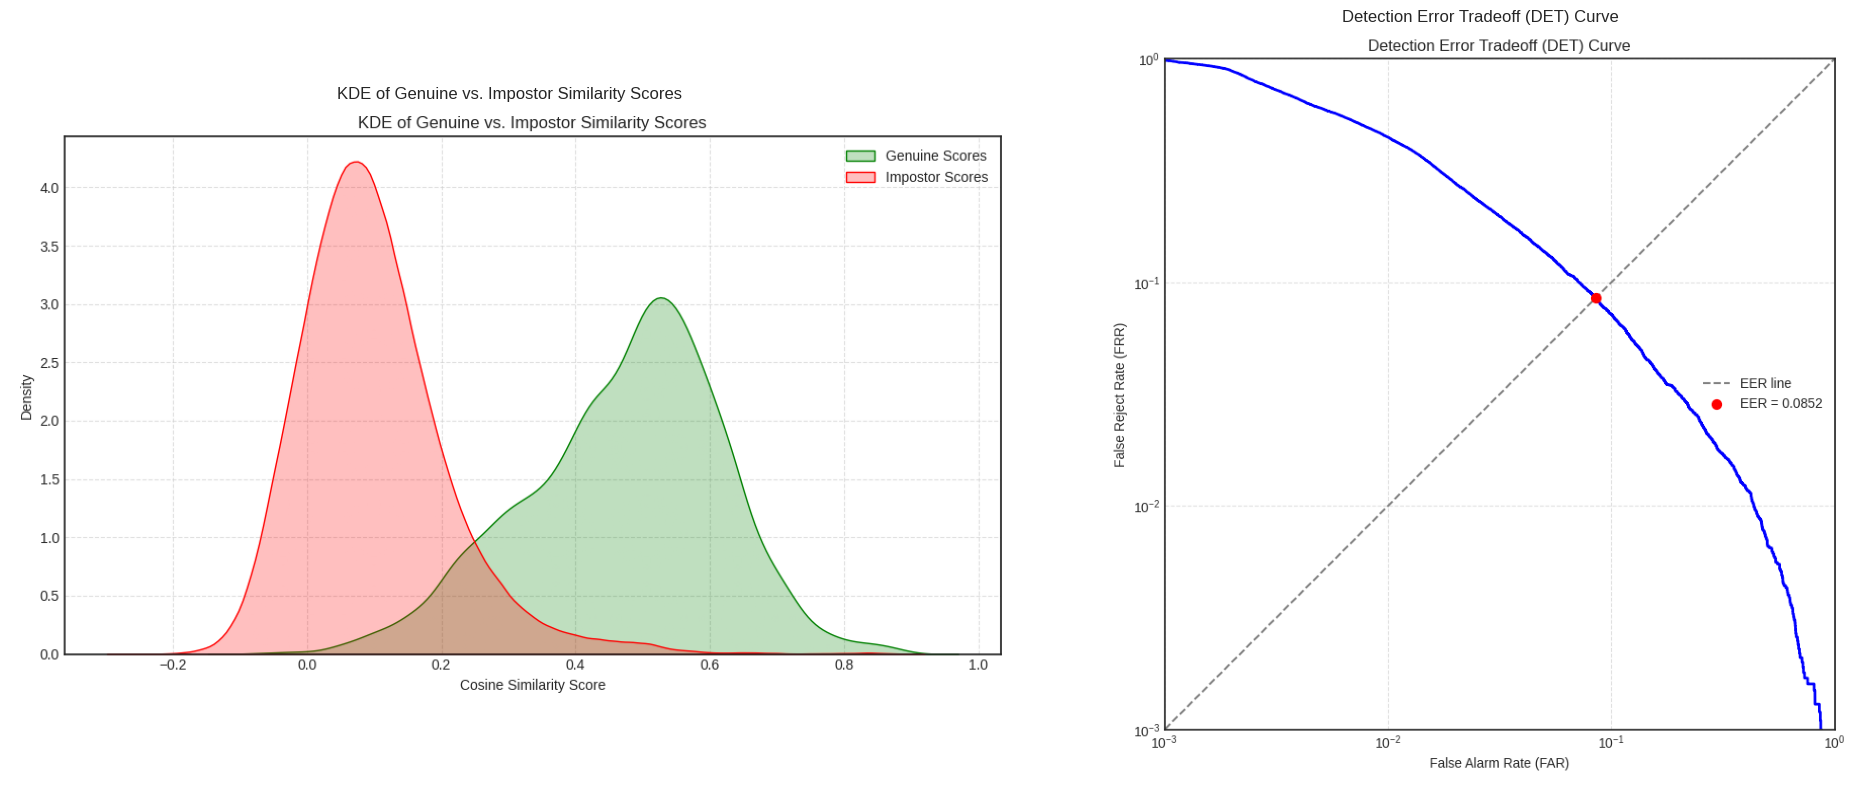

KDE histogram and DET curve displayed as subplots.

--- Re-displaying other previously generated plots ---

Speaker Identification t-SNE Plot:


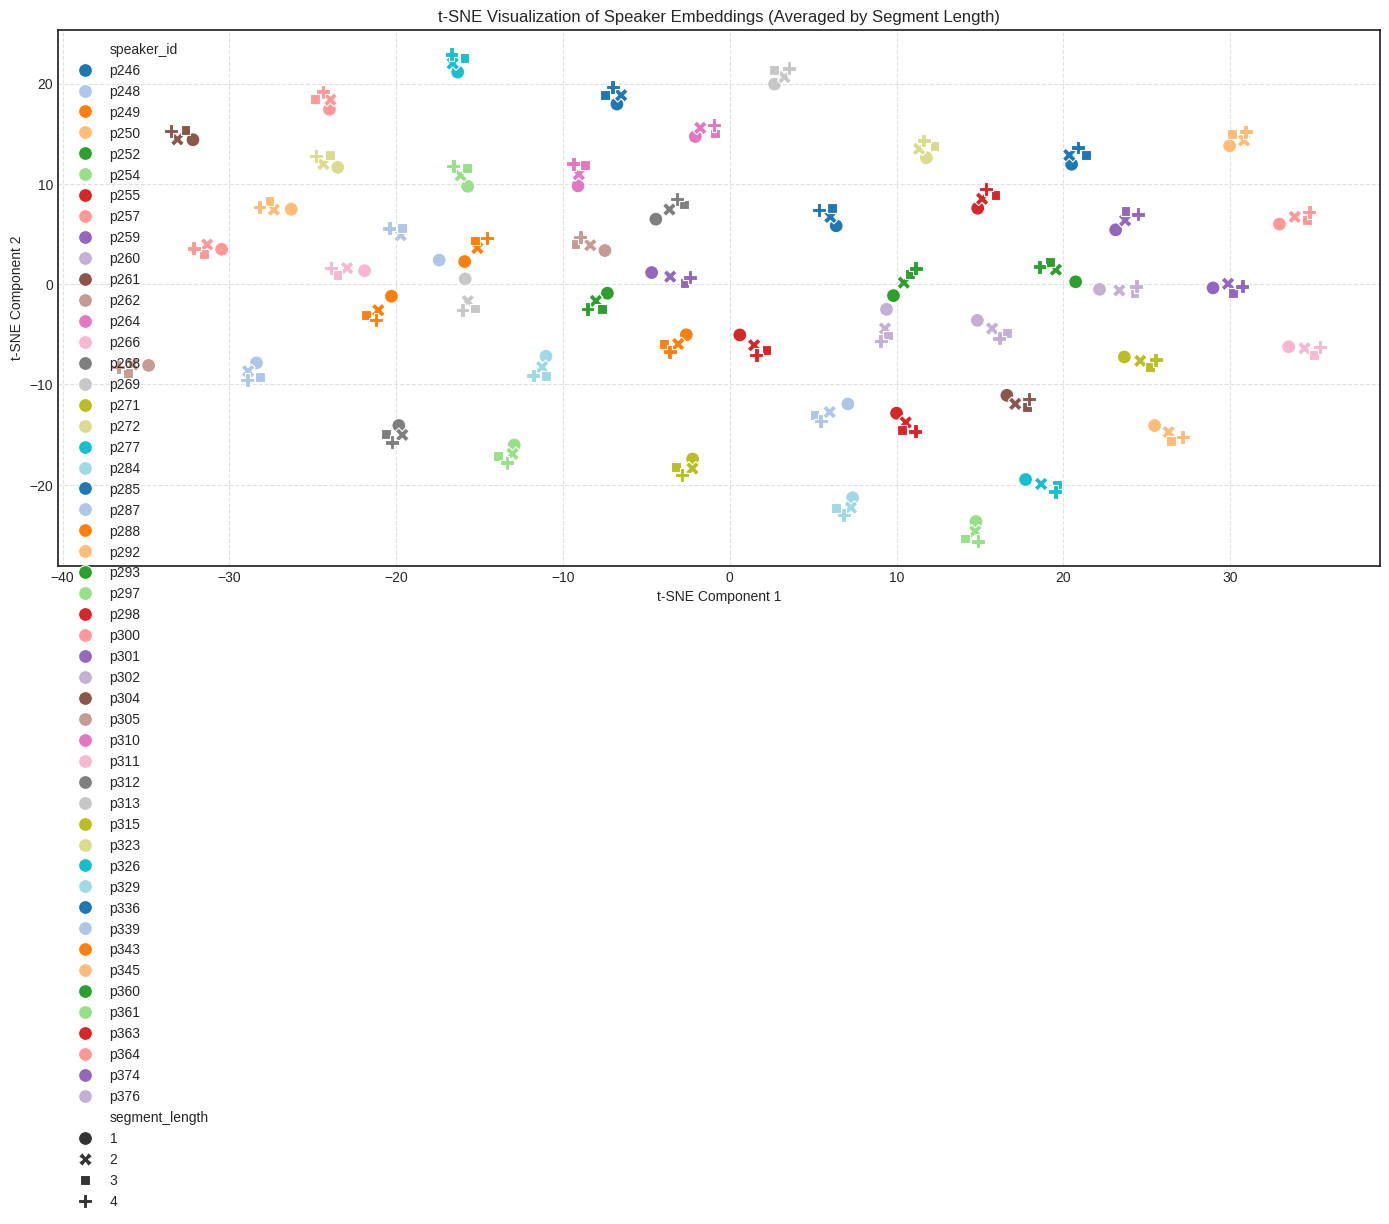


Utterance Segment Identification t-SNE Plot:


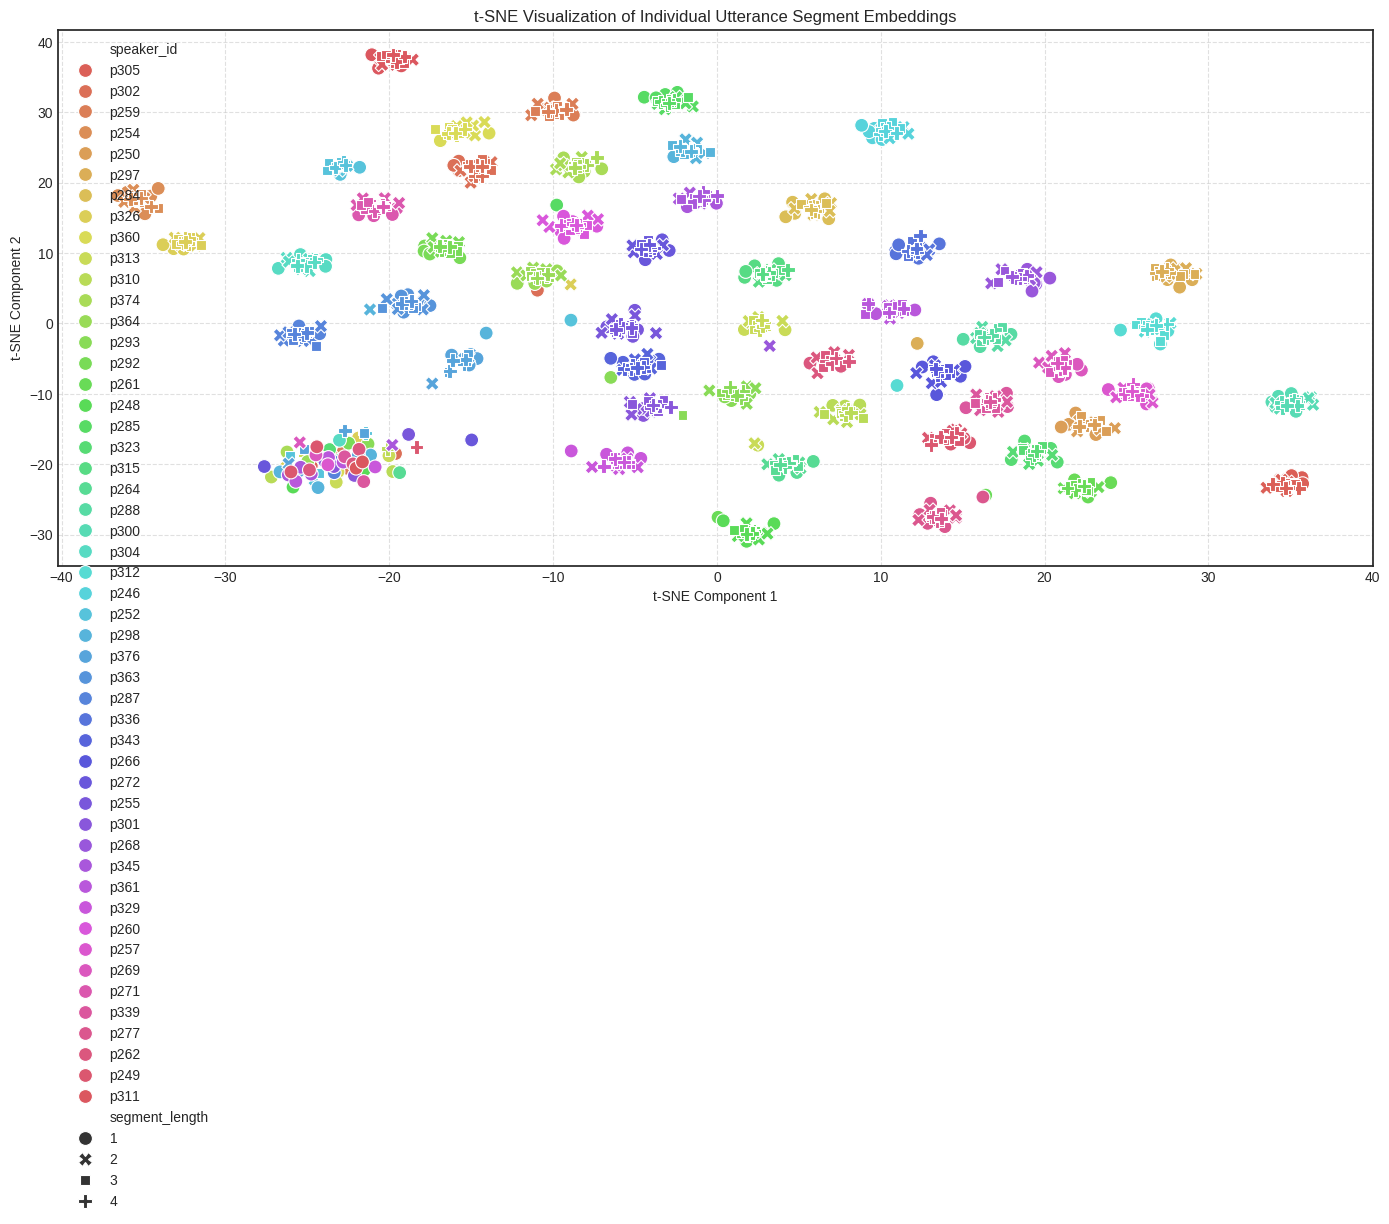


Confusion Matrix for Speaker Identification:


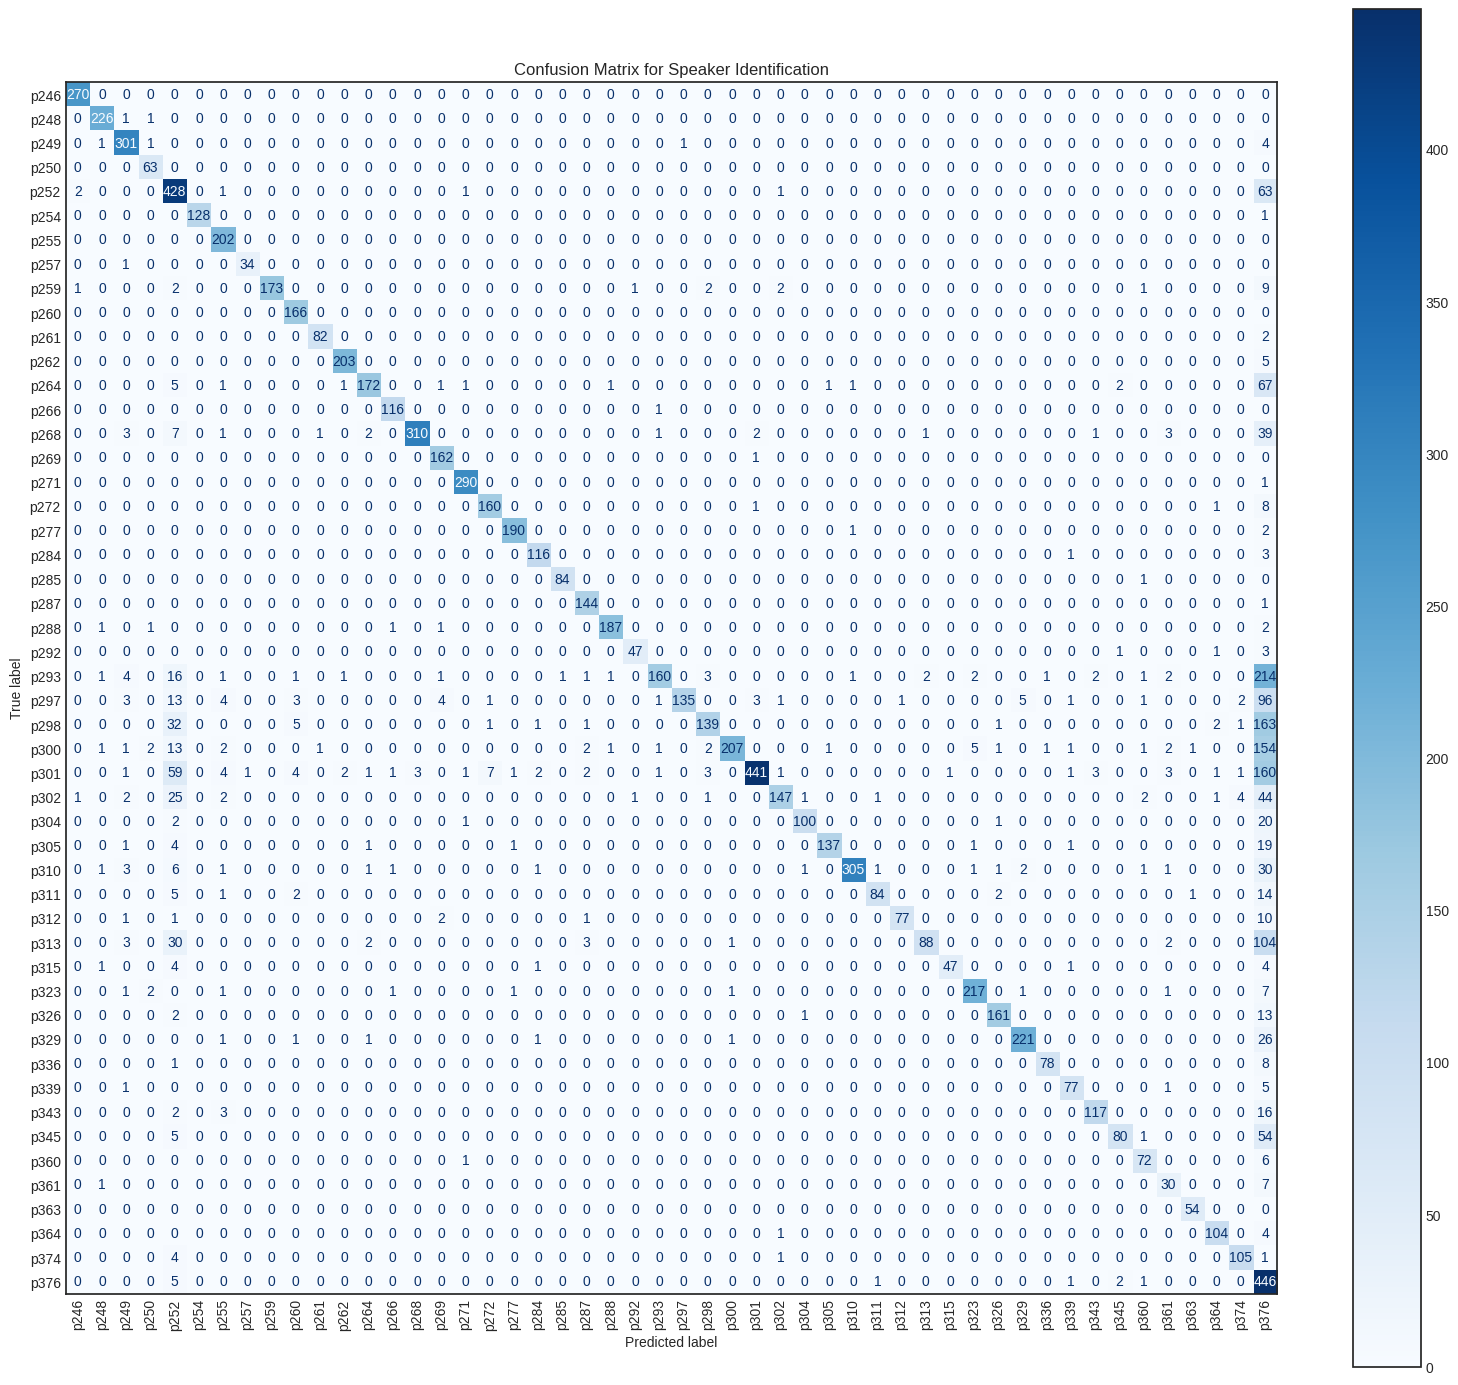

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from IPython.display import Image, display

# Ensure plots_output_dir is defined from previous cells
if 'plots_output_dir' not in locals():
    print("plots_output_dir variable not found. Please ensure previous setup cells have been run.")
else:
    kde_plot_path = os.path.join(plots_output_dir, "kde_genuine_impostor_scores.png")
    det_plot_path = os.path.join(plots_output_dir, "det_curve.png")

    if os.path.exists(kde_plot_path) and os.path.exists(det_plot_path):
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Display KDE Plot
        img_kde = mpimg.imread(kde_plot_path)
        axes[0].imshow(img_kde)
        axes[0].set_title('KDE of Genuine vs. Impostor Similarity Scores')
        axes[0].axis('off') # Hide axes ticks

        # Display DET Curve Plot
        img_det = mpimg.imread(det_plot_path)
        axes[1].imshow(img_det)
        axes[1].set_title('Detection Error Tradeoff (DET) Curve')
        axes[1].axis('off') # Hide axes ticks

        plt.tight_layout()
        plt.show()
        print("KDE histogram and DET curve displayed as subplots.")
    else:
        print(f"One or both plots not found: KDE at {kde_plot_path}, DET at {det_plot_path}")

    # Re-display other plots
    print("\n--- Re-displaying other previously generated plots ---")

    speaker_tsne_path = os.path.join(plots_output_dir, "tsne_speaker_identification.png")
    segment_tsne_path = os.path.join(plots_output_dir, "tsne_utterance_segments_identification.png")
    confusion_matrix_path = os.path.join(plots_output_dir, "confusion_matrix_speaker_id.png")

    if os.path.exists(speaker_tsne_path):
        print("\nSpeaker Identification t-SNE Plot:")
        display(Image(filename=speaker_tsne_path))
    else:
        print(f"Speaker t-SNE plot not found at {speaker_tsne_path}")

    if os.path.exists(segment_tsne_path):
        print("\nUtterance Segment Identification t-SNE Plot:")
        display(Image(filename=segment_tsne_path))
    else:
        print(f"Utterance segment t-SNE plot not found at {segment_tsne_path}")

    if os.path.exists(confusion_matrix_path):
        print("\nConfusion Matrix for Speaker Identification:")
        display(Image(filename=confusion_matrix_path))
    else:
        print(f"Confusion matrix plot not found at {confusion_matrix_path}")